---
format: 
    html:
        page-layout: full
        embed-resources: True
        grid:
            body-width: 1200px
        fontsize: 18px
        code-fold: true
        code-summary: "Show the code"
        code-tools: true
        code-copy: false
        number-sections: true

title: Cross-sectional sector momentum strategy - Case Study
author: Rui Carvalho Caseiro
date: last-modified

warning: False
toc: True
---

In [1]:
import pandas as pd
pd.options.display.float_format = '{:.2f}'.format
import numpy as np
import plotly.io as pio
pio.renderers.default = "plotly_mimetype+notebook_connected"

import warnings
warnings.filterwarnings("ignore")

import MyCustomLibrary.main as main
import MyCustomLibrary.backtester as bt
import MyCustomLibrary.backtester_tools as tools
import MyCustomLibrary.features as my_ta

## Study overview

This study evaluates the effectiveness of cross-sectional sector momentum using the 10 industry portfolios from the Fama-French Data Library:

**NoDur, Durbl, Manuf, Enrgy, HiTec, Telcm, Shops, Hlth, Utils, and Other.**

The dataset consists of equally weighted monthly total returns from July 1926 through March 2026.

The analysis explores multiple momentum formation windows (1, 3, 6, 9, and 12 months), as well as composite momentum signals combining several lookback horizons. Portfolio concentration is also tested by varying the number of selected industries from 1 to 5.

The central question is straightforward:

    Can sector momentum improve risk-adjusted returns relative to Buy & Hold and Equal-Weight benchmarks?

### Signals construction:
- **BUY RULE:** Allocate capital to the top X ranked sectors based on positive trailing momentum.
- **SELL RULE:** Remove sectors that fall outside the top X ranking or get negative momentum.

### Backtest assumptions
1.  Signals are generated using end-of-month data and executed at the following month’s open to eliminate look-ahead bias.
2.  All return series are total return indices including reinvested dividends.
3.  A transaction cost of 15 bps per trade is applied to account for implementation frictions.
4.  Positions are equally weighted across selected sectors (1 / Top X). If fewer than X valid positions are available, the remaining capital is held in cash until the next rebalance period.


###  Key findings:
- Longer-term momentum (ROC9–ROC12) consistently outperformed shorter lookbacks.
- Highly concentrated Top1 portfolios proved highly unstable and unreliable.
- ROC12 Top4 delivered the strongest robustness profile in-sample.
- Out-of-sample, momentum strategy achieved similar CAGR but substantially reduced volatility and drawdowns.
- The strategy’s main edge appears defensive rather than return-maximizing.

### Limitations:
- Monthly data ignores intramonth volatility and execution dynamics.
- Artificial next-month open prices were approximated using prior closes.
- Sector definitions from Fama-French are static and may not fully reflect modern sector composition.
- The study does not account for taxes, slippage, or market impact.

## Data

The dataset consists of equally weighted monthly total returns from July 1926 through March 2026 from the Fama-French Data Library.

In [2]:
# | include: false

def get_ind_returns(weighting: str, n_inds: int)-> pd.DataFrame:
    """ 
    Get the industry portfolios returns.
    """
    ind = pd.read_csv(
        fr"C:/Users/Rui Caseiro/Nextcloud/002_Learning/000_Local_Pyhton_Packages/MyDataLibrary/csv_10_30_49_Industry_Portfolios/ind{n_inds}_m_{weighting}_rets.csv",
        header=0, index_col=0, na_values=-99.99)/100
    
    ind.index = pd.to_datetime(ind.index, format="%Y%m")
    ind.columns = ind.columns.str.strip()

    return ind

get_ind_returns(weighting='ew', n_inds=10).head(3)

,NoDur,Durbl,Manuf,Enrgy,HiTec,Telcm,Shops,Hlth,Utils,Other
1926-07-01,0.01,0.04,0.02,-0.02,0.02,0.01,0.01,0.03,0.05,0.00
1926-08-01,0.05,0.00,0.02,0.04,0.03,0.01,-0.00,0.06,-0.02,0.04
1926-09-01,0.00,-0.03,0.01,-0.03,0.01,0.00,-0.01,0.01,0.02,-0.00


In [3]:
def add_artificial_close_open_to_rets(rets_df: pd.DataFrame) -> pd.DataFrame:

    rets = rets_df.copy()

    # Build cumulative price series
    close_prices = rets.add(1).cumprod()

    # Artificial next-period open
    open_prices = close_prices.shift(1)

    # Add MultiIndex columns
    rets.columns = pd.MultiIndex.from_product(
        [rets.columns, ['Return']]
    )

    close_prices.columns = pd.MultiIndex.from_product(
        [close_prices.columns, ['Close']]
    )

    open_prices.columns = pd.MultiIndex.from_product(
        [open_prices.columns, ['Open']]
    )

    # Combine
    result = pd.concat([open_prices, close_prices, rets], axis=1).sort_index(axis=1)

    return result.dropna(axis=0)

In [4]:
#| code-fold: show

ind_quotes = add_artificial_close_open_to_rets(
    get_ind_returns(weighting='ew', n_inds=10)
)
ind_quotes

Durbl                   Enrgy                     HiTec  \
             Close    Open Return    Close     Open Return     Close   
1926-08-01    1.04    1.04   0.00     1.02     0.98   0.04      1.05   
1926-09-01    1.01    1.04  -0.03     0.99     1.02  -0.03      1.06   
1926-10-01    0.91    1.01  -0.10     1.01     0.99   0.03      1.00   
1926-11-01    0.91    0.91  -0.00     1.03     1.01   0.01      1.01   
1926-12-01    0.95    0.91   0.05     1.08     1.03   0.05      1.02   
...            ...     ...    ...      ...      ...    ...       ...   
2025-11-01 7324.85 7420.58  -0.01 32824.22 32631.69   0.01 243161.81   
2025-12-01 6958.61 7324.85  -0.05 31862.47 32824.22  -0.03 238274.26   
2026-01-01 7591.15 6958.61   0.09 36979.58 31862.47   0.16 245636.93   
2026-02-01 7505.37 7591.15  -0.01 39039.35 36979.58   0.06 234534.14   
2026-03-01 6829.13 7505.37  -0.09 44094.94 39039.35   0.13 224707.16   

                                 Hlth  ...  Other    Shops                  \
                Open Return     Close  ... Return    Close     Open Return   
1926-08-01      1.02   0.03      1.09  ...   0.04     1.01     1.01  -0.00   
1926-09-01      1.05   0.01      1.10  ...  -0.00     1.00     1.01  -0.01   
1926-10-01      1.06  -0.06      1.10  ...  -0.03     0.97     1.00  -0.03   
1926-11-01      1.00   0.01      1.18  ...   0.01     0.98     0.97   0.01   
1926-12-01      1.01   0.01      1.18  ...   0.01     1.01     0.98   0.03   
...              ...    ...       ...  ...    ...      ...      ...    ...   
2025-11-01 264220.16  -0.08 149556.15  ...   0.01 47529.90 47980.93  -0.01   
2025-12-01 243161.81  -0.02 143693.55  ...   0.01 46132.53 47529.90  -0.03   
2026-01-01 238274.26   0.03 145130.48  ...   0.03 48540.64 46132.53   0.05   
2026-02-01 245636.93  -0.05 146581.79  ...  -0.02 47963.01 48540.64  -0.01   
2026-03-01 234534.14  -0.04 137391.11  ...  -0.04 45353.82 47963.01  -0.05   

              Telcm                    Utils                  
              Close     Open Return    Close     Open Return  
1926-08-01     1.02     1.01   0.01     1.03     1.05  -0.02  
1926-09-01     1.03     1.02   0.00     1.05     1.03   0.02  
1926-10-01     1.02     1.03  -0.01     1.01     1.05  -0.03  
1926-11-01     1.03     1.02   0.01     1.08     1.01   0.06  
1926-12-01     1.05     1.03   0.02     1.09     1.08   0.02  
...             ...      ...    ...      ...      ...    ...  
2025-11-01 81668.77 82761.21  -0.01 63026.73 59820.36   0.05  
2025-12-01 84641.51 81668.77   0.04 60663.23 63026.73  -0.04  
2026-01-01 87172.29 84641.51   0.03 63368.81 60663.23   0.04  
2026-02-01 90232.04 87172.29   0.04 67506.79 63368.81   0.07  
2026-03-01 87019.78 90232.04  -0.04 66824.97 67506.79  -0.01  

[1196 rows x 30 columns]

### Data Integrity check

In [5]:
# ind_quotes.shape
# ind_quotes.columns
# ind_quotes.isna().sum()
ind_quotes.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1196 entries, 1926-08-01 to 2026-03-01
Data columns (total 30 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Durbl, Close)   1196 non-null   float64
 1   (Durbl, Open)    1196 non-null   float64
 2   (Durbl, Return)  1196 non-null   float64
 3   (Enrgy, Close)   1196 non-null   float64
 4   (Enrgy, Open)    1196 non-null   float64
 5   (Enrgy, Return)  1196 non-null   float64
 6   (HiTec, Close)   1196 non-null   float64
 7   (HiTec, Open)    1196 non-null   float64
 8   (HiTec, Return)  1196 non-null   float64
 9   (Hlth, Close)    1196 non-null   float64
 10  (Hlth, Open)     1196 non-null   float64
 11  (Hlth, Return)   1196 non-null   float64
 12  (Manuf, Close)   1196 non-null   float64
 13  (Manuf, Open)    1196 non-null   float64
 14  (Manuf, Return)  1196 non-null   float64
 15  (NoDur, Close)   1196 non-null   float64
 16  (NoDur, Open)    1196 non-null   float64
 

All data is complete, Numbers formatting is correct!

### Data prep

Momentum features are computed for each of the 10 industry portfolios using trailing returns over 1, 3, 6, 9, and 12-month formation windows and a composite momentum signal.

Since the longest lookback requires 12 months of historical data, the initial observations are removed to ensure a fully populated feature set across all momentum horizons.

In [6]:
def df_add_strategy_factors(quotes_df: pd.DataFrame, lookbacks: list) -> pd.DataFrame:
    ''' 
        Input: Feed a Multi Level DataFrame with several assets prices
        Output: Get the same Data Frame plus Several indicators for each symbol
    '''
    symbols = quotes_df.columns.get_level_values(0).unique()
    result_df = pd.DataFrame()

    for symbol in symbols:
        close_series = quotes_df[(symbol, 'Close')]

        new_columns = {}

        for lookback in lookbacks:
            new_columns[f'ROC{lookback}'] = my_ta.get_ROC(close_series, lookback)

        symbol_df = pd.DataFrame(new_columns)

        # blended signal
        symbol_df['ROCcombo'] = symbol_df.mean(axis=1)

        symbol_df.columns = pd.MultiIndex.from_product([[symbol], symbol_df.columns])
        result_df = pd.concat([result_df, symbol_df], axis=1)
        
    result_df = pd.concat([quotes_df, result_df], axis=1).sort_index(axis=1)
        
    return result_df

main.timer.start()
screened_df = df_add_strategy_factors(quotes_df=ind_quotes, lookbacks=[1, 3, 6, 9, 12])
screened_df.dropna(axis=0, inplace=True)
main.timer.stop()

screened_df


[*] Total runtime: 34.66 ms


Durbl                                                        \
             Close    Open  ROC1 ROC12  ROC3  ROC6  ROC9 ROCcombo Return   
1927-08-01    1.03    1.01  0.02 -0.01  0.04  0.04  0.13     0.04   0.02   
1927-09-01    1.02    1.03 -0.01  0.01  0.07  0.06  0.07     0.04  -0.01   
1927-10-01    0.98    1.02 -0.04  0.08 -0.03  0.03  0.06     0.02  -0.04   
1927-11-01    1.10    0.98  0.11  0.21  0.06  0.10  0.11     0.12   0.11   
1927-12-01    1.17    1.10  0.07  0.23  0.14  0.23  0.21     0.18   0.07   
...            ...     ...   ...   ...   ...   ...   ...      ...    ...   
2025-11-01 7324.85 7420.58 -0.01 -0.26 -0.07  0.04 -0.09    -0.08  -0.01   
2025-12-01 6958.61 7324.85 -0.05 -0.24 -0.13 -0.03 -0.02    -0.09  -0.05   
2026-01-01 7591.15 6958.61  0.09 -0.15  0.02  0.02  0.11     0.02   0.09   
2026-02-01 7505.37 7591.15 -0.01 -0.07  0.02 -0.05  0.07    -0.01  -0.01   
2026-03-01 6829.13 7505.37 -0.09 -0.04 -0.02 -0.14 -0.04    -0.07  -0.09   

              Enrgy  ...  Telcm    Utils                                      \
              Close  ... Return    Close     Open  ROC1 ROC12 ROC3 ROC6 ROC9   
1927-08-01     1.08  ...   0.01     1.39     1.31  0.06  0.35 0.07 0.21 0.29   
1927-09-01     1.13  ...   0.05     1.52     1.39  0.09  0.45 0.21 0.30 0.39   
1927-10-01     1.07  ...  -0.02     1.45     1.52 -0.05  0.43 0.10 0.22 0.33   
1927-11-01     1.18  ...   0.04     1.53     1.45  0.06  0.43 0.11 0.18 0.34   
1927-12-01     1.18  ...   0.03     1.56     1.53  0.02  0.43 0.03 0.24 0.34   
...             ...  ...    ...      ...      ...   ...   ...  ...  ...  ...   
2025-11-01 32824.22  ...  -0.01 63026.73 59820.36  0.05  0.14 0.10 0.12 0.16   
2025-12-01 31862.47  ...   0.04 60663.23 63026.73 -0.04  0.17 0.02 0.07 0.09   
2026-01-01 36979.58  ...   0.03 63368.81 60663.23  0.04  0.21 0.06 0.11 0.15   
2026-02-01 39039.35  ...   0.04 67506.79 63368.81  0.07  0.24 0.07 0.17 0.20   
2026-03-01 44094.94  ...  -0.04 66824.97 67506.79 -0.01  0.20 0.10 0.12 0.18   

                            
           ROCcombo Return  
1927-08-01     0.20   0.06  
1927-09-01     0.29   0.09  
1927-10-01     0.21  -0.05  
1927-11-01     0.22   0.06  
1927-12-01     0.21   0.02  
...             ...    ...  
2025-11-01     0.11   0.05  
2025-12-01     0.06  -0.04  
2026-01-01     0.11   0.04  
2026-02-01     0.15   0.07  
2026-03-01     0.12  -0.01  

[1184 rows x 90 columns]

###  Benchmarks generation

#### Naive equally weighted portfolio

A naive equal weighting portfolio is generated in order to serve as benchmark against Sector rotation strategy. This naive portfolio is consisted of the 10 industry portfolios, fully invested for the whole period with equal weights monthly rebalanced.

In [7]:
#| code-fold: show

def generate_ew_portfolio(quotes_df):

    rets = quotes_df.xs(f'Return', level=1, axis=1)

    ew_portfolio = rets.mean(axis=1).add(1).cumprod()
    ew_portfolio.name = 'ew_portfolio'

    return ew_portfolio

ew_portfolio = generate_ew_portfolio(screened_df)
ew_portfolio

1927-08-01        1.01
1927-09-01        1.05
1927-10-01        1.02
1927-11-01        1.11
1927-12-01        1.13
                ...   
2025-11-01    99434.61
2025-12-01    97375.32
2026-01-01   103208.10
2026-02-01   104310.36
2026-03-01   100732.52
Name: ew_portfolio, Length: 1184, dtype: float64

#### Naive Buy & Hold portfolio

A naive buy & hold portfolio is generated in order to serve as benchmark against Sector rotation strategy. This naive portfolio is consisted of the 10 industry portfolios, fully invested for the whole period with initial equal weights.

In [8]:
def generate_buy_hold_portfolio(quotes_df):

    close_prices = quotes_df.xs(f'Close', level=1, axis=1)

    initial_prices = close_prices.iloc[0]
    n_assets = len(initial_prices)

    # equal capital allocation at t0
    initial_weights = pd.Series(1 / n_assets, index=initial_prices.index)

    # normalize prices to 1 at start, then weight them
    rel_prices = close_prices[initial_prices.index].div(initial_prices)

    buy_hold_portfolio = (rel_prices * initial_weights).sum(axis=1)
    buy_hold_portfolio.name = "buy_hold_portfolio"

    return buy_hold_portfolio

bh_portfolio = generate_buy_hold_portfolio(screened_df)
bh_portfolio

1927-08-01       1.00
1927-09-01       1.04
1927-10-01       1.01
1927-11-01       1.10
1927-12-01       1.12
               ...   
2025-11-01   70402.72
2025-12-01   69401.45
2026-01-01   72618.15
2026-02-01   72628.11
2026-03-01   69960.76
Name: buy_hold_portfolio, Length: 1184, dtype: float64

## Backtesting

### Signals construction:
- **BUY RULE:** Allocate capital to the top X ranked sectors based on trailing momentum.
- **SELL RULE:** Remove sectors that fall outside the top X ranking.

In [9]:
#| code-fold: show

def get_tradable_tickers(quotes:pd.DataFrame, roc_lookback:int, row:int, top_X:int, min_roc:float|None)-> list:

    roc_series = quotes.xs(f'ROC{roc_lookback}', level=1, axis=1)

    row_roc = roc_series.iloc[row]

    if min_roc is not None:
        row_roc = row_roc[row_roc > min_roc]

    return row_roc.nlargest(top_X).index.tolist()

In [10]:
# | include: false

# row = 420

# print("No ROC Threshold:", get_tradable_tickers(screened_df, roc_lookback=12, row=row, top_X=5, min_roc=None))
# print("Positive ROC Threshold:", get_tradable_tickers(screened_df, roc_lookback=12, row=row, top_X=5, min_roc=0))
# print(screened_df.xs(f'ROC{12}', level=1, axis=1).iloc[row].sort_values(ascending=False))

In [11]:
# | include: false

# row = 411

# old_tickers = get_tradable_tickers(screened_df, roc_lookback=12, row=row-2, top_X=5, min_roc=0)
# new_tickers = get_tradable_tickers(screened_df, roc_lookback=12, row=row-1, top_X=5, min_roc=0)

# sell_tickers =  list(set(old_tickers) - set(new_tickers))
# hold_tickers =  list(set(old_tickers) & set(new_tickers))
# buy_tickers =   list(set(new_tickers) - set(old_tickers))

# print("Sell Tickers:", sell_tickers)
# print("Hold Tickers:", hold_tickers)
# print("Buy Tickers:", buy_tickers)

In [12]:
def get_rebalance_size(
        symbol_target_exposure: float,
        symbol_current_exposure: float,
        symbol_price: float,
        equity_value: float,
        rebalance_threshold: float=0.0
    ):

    rebalancing_delta = (symbol_target_exposure-0.005) - symbol_current_exposure

    if abs(rebalancing_delta) < rebalance_threshold:
        return 0

    rebalancing_size = tools.position_size_Fixed_Fractional(
                            equity_value=equity_value,
                            price=symbol_price,
                            portfolio_weight=rebalancing_delta
                        )
    
    return rebalancing_size

### Strategy Implementation

In [13]:
class SectorRotationStrategy(bt.Strategy):
    
    def init(self,
             roc_lookback: int,
             top_X: int,
             **kwargs
             ):
        
        self.roc_lookback = roc_lookback
        self.top_X = top_X
        
        self.min_roc = kwargs.get("min_roc", None)

    def next(self, i, record):

        try:
            equity_value = (self.assets_value + self.cash)
            
            old_tickers = get_tradable_tickers(self.data, self.roc_lookback, row=i-2, top_X=self.top_X, min_roc=self.min_roc)
            new_tickers = get_tradable_tickers(self.data, self.roc_lookback, row=i-1, top_X=self.top_X, min_roc=self.min_roc)

            sell_tickers =  list(set(old_tickers) - set(new_tickers))
            hold_tickers =  list(set(old_tickers) & set(new_tickers))
            buy_tickers =   list(set(new_tickers) - set(old_tickers))

            # nr_positions = len(hold_tickers)+len(buy_tickers)

            ###------------Sell conditions------------###

            for symbol in sell_tickers:

                self.close(
                    symbol=symbol, 
                    price=record[(symbol,'Open')],
                    why_exit=f'Dropped Top{self.top_X}'
                )

            ###------------Rebalancing conditions------------###

            for symbol in hold_tickers:

                symbol_price = record[(symbol,'Close')]
                symbol_target_exposure = 1/self.top_X
                symbol_current_exposure = self.symbol_total_positions_exposure(symbol)

                rebalance_size = get_rebalance_size(symbol_target_exposure, symbol_current_exposure,
                                                    symbol_price, equity_value, rebalance_threshold=0.0)
                
                if rebalance_size == 0:
                    pass
                
                elif rebalance_size > 0:
                    # Buy
                    self.open_long(symbol=symbol, price=symbol_price, size=int(rebalance_size)-1)

                else:
                    # Sell
                    self.close(symbol=symbol, price=symbol_price, size=int(abs(rebalance_size))+1, why_exit='Rebalancing')


            ###------------Buy conditions------------###

            for symbol in buy_tickers:

                self.open_long(
                    symbol=symbol, 
                    price=record[(symbol,'Open')], 
                    size=tools.position_size_Equal_Weighting(
                        equity_value=equity_value,
                        price=record[(symbol,'Open')],
                        nr_desired_positions=self.top_X
                    )
                )
                        
        except Exception as e:
            import traceback
            print(traceback.format_exc())

In [14]:
# | include: false
# Limited testing to see if everything is working as intended.

# lt_backtest = bt.Backtest(SectorRotationStrategy, screened_df.iloc[:100], cash=100_000, commission=0.00)
# lt_result = lt_backtest.run(roc_lookback='combo', top_X=5, close_on_last_bar=True)

# tools.metrics_returns_and_trades(lt_result.returns, lt_result.trades, steps_per_year=12, rf=0.0)

In [15]:
# | include: false

# main.plot_strategy_performance(lt_result.returns)

In [16]:
# | include: false

# lt_result.trades

### In Sample Optimization - Training Data

> It is important that the basic buy-and-sell rules are successful across a range of calculation periods and similar markets. If this fails, then you need to rethink your idea. I don’t believe in adding rules to make the strategy more complex in the hope that one rule will turn a losing idea into a profitable one. It is necessary that the basic concept is robust before moving forward. Then we can try to make it better.
> — Perry Kaufman

- The robustness of the momentum effect is evaluated across multiple formation windows (1, 3, 6, 9, and 12 months), including composite signals that combine several lookback horizons.

- Portfolio concentration is also varied by selecting the top 1 to 5 ranked industries. The objective is to evaluate the stability of results across different parameter configurations rather than optimizing for a single specification.

- The full sample spans nearly a century of data, from August 1927 through March 2026. To evaluate out-of-sample robustness, the dataset is divided into two periods:

    - In-sample: August 1927 – June 2006 (80%)
    - Out-of-sample: July 2006 – March 2026 (20%)

- Positions are only initiated or maintained when momentum is positive. As a result, the portfolio may occasionally hold fewer than the target number of positions, with unallocated capital remaining in cash.

- A transaction cost assumption of 15 bps per trade is included to account for implementation frictions and portfolio turnover.

- Portfolios are rebalanced monthly, with positions resized back to equal weights at each rebalance date.

In [17]:
#| code-fold: show

df_train, df_test = main.train_test_split(screened_df, test_size=0.2)

is_optimization = bt.Optimization(SectorRotationStrategy, df_train, cash=100_000, commission=0.0015)

roc_lookbacks = [1, 3, 6, 9, 12, 'combo']

top_X_list = np.arange(1,6).tolist()

values = [
    roc_lookbacks,
    top_X_list
    ]

main.timer.start()
is_optimization.run(values, min_roc=0)
main.timer.stop()

Optimization Progress:   0%|          | 0/30 [00:00<?, ?it/s]

Optimization Progress:   3%|▎         | 1/30 [00:01<00:30,  1.06s/it]

Optimization Progress:   7%|▋         | 2/30 [00:02<00:29,  1.06s/it]

Optimization Progress:  10%|█         | 3/30 [00:03<00:28,  1.07s/it]

Optimization Progress:  13%|█▎        | 4/30 [00:04<00:28,  1.10s/it]

...

Optimization Progress:  93%|█████████▎| 28/30 [00:31<00:02,  1.15s/it]

Optimization Progress:  97%|█████████▋| 29/30 [00:32<00:01,  1.20s/it]

Optimization Progress: 100%|██████████| 30/30 [00:33<00:00,  1.22s/it]

Optimization Progress: 100%|██████████| 30/30 [00:33<00:00,  1.12s/it]


[*] Total runtime: 33.68 s


#### Returns Analysis

In [18]:
bt_lookbacks = pd.concat([bh_portfolio, ew_portfolio, is_optimization.equity_curves()], axis=1).dropna(axis=0)

main.plot_comparative_graph(bt_lookbacks)

At first glance, it appears to exist 2 distinct performance clusters.

There's the upper cluster that's highly correlated and performs well in which most configurations track each other closely over nearly a century of data, despite meaningful differences in lookback horizons and portfolio concentration.

The lower cluster which doesn't perform well and is highly uncorrelated is only constituted by Top1 variations.

Fisrt cluster is usually a good sign, when a strategy family produces similar outcomes across a broad parameter space, it suggests the underlying effect may be structurally persistent rather than dependent on a narrowly optimized specification.

In [19]:
strats_performance =  pd.concat(
    [tools.strategy_performance_metrics(bt_lookbacks, steps_per_year=12, rf=0.0), 
    is_optimization.optimization_trades_stats()], 
    axis='index'
    ).fillna('-')

strats_performance

,buy_hold_portfolio,ew_portfolio,1x1,1x2,1x3,1x4,1x5,3x1,3x2,3x3,...,12x1,12x2,12x3,12x4,12x5,combox1,combox2,combox3,combox4,combox5
CAGR %,13.51,13.72,-0.46,13.66,16.16,16.71,16.50,4.03,17.51,17.12,...,9.55,18.53,17.90,17.52,16.73,7.23,20.85,19.80,18.29,17.35
Ann. Vola %,25.10,24.40,4.23,16.42,18.67,19.37,19.57,13.93,20.96,20.72,...,19.03,22.16,21.50,20.49,19.90,18.36,22.63,21.75,20.49,19.96
Max Drawdown %,-83.68,-83.80,-47.05,-48.92,-60.63,-59.64,-66.24,-48.64,-62.23,-70.35,...,-57.63,-65.75,-65.19,-63.09,-61.49,-83.80,-54.55,-59.29,-59.08,-56.03
VaR 5%,-9.42,-8.59,-0.15,-4.86,-5.67,-5.36,-5.41,-2.89,-6.08,-6.25,...,-7.13,-7.39,-6.68,-6.70,-6.24,-6.37,-7.36,-6.91,-6.43,-5.95
Time in Market %,100.00,100.00,26.85,95.77,95.77,95.77,95.77,67.23,92.28,92.28,...,86.36,94.29,94.29,94.29,94.29,78.44,93.97,93.97,93.97,93.97
Sharpe,0.54,0.56,-0.11,0.83,0.87,0.86,0.84,0.29,0.84,0.83,...,0.50,0.84,0.83,0.85,0.84,0.39,0.92,0.91,0.89,0.87
Sortino,0.80,0.83,-0.07,1.39,1.43,1.50,1.44,0.38,1.20,1.13,...,0.69,1.18,1.21,1.21,1.18,0.50,1.41,1.32,1.26,1.21
Calmar,0.16,0.16,-0.01,0.28,0.27,0.28,0.25,0.08,0.28,0.24,...,0.17,0.28,0.27,0.28,0.27,0.09,0.38,0.33,0.31,0.31
Efficiency,0.14,0.14,-0.02,0.14,0.17,0.17,0.17,0.06,0.19,0.19,...,0.11,0.20,0.19,0.19,0.18,0.09,0.22,0.21,0.19,0.18
Nr trades,-,-,116.00,1099.00,1940.00,2655.00,3272.00,291.00,1386.00,2199.00,...,567.00,1594.00,2418.00,3177.00,3891.00,307.00,1568.00,2410.00,3169.00,3879.00


#### Parameters Sensitivity

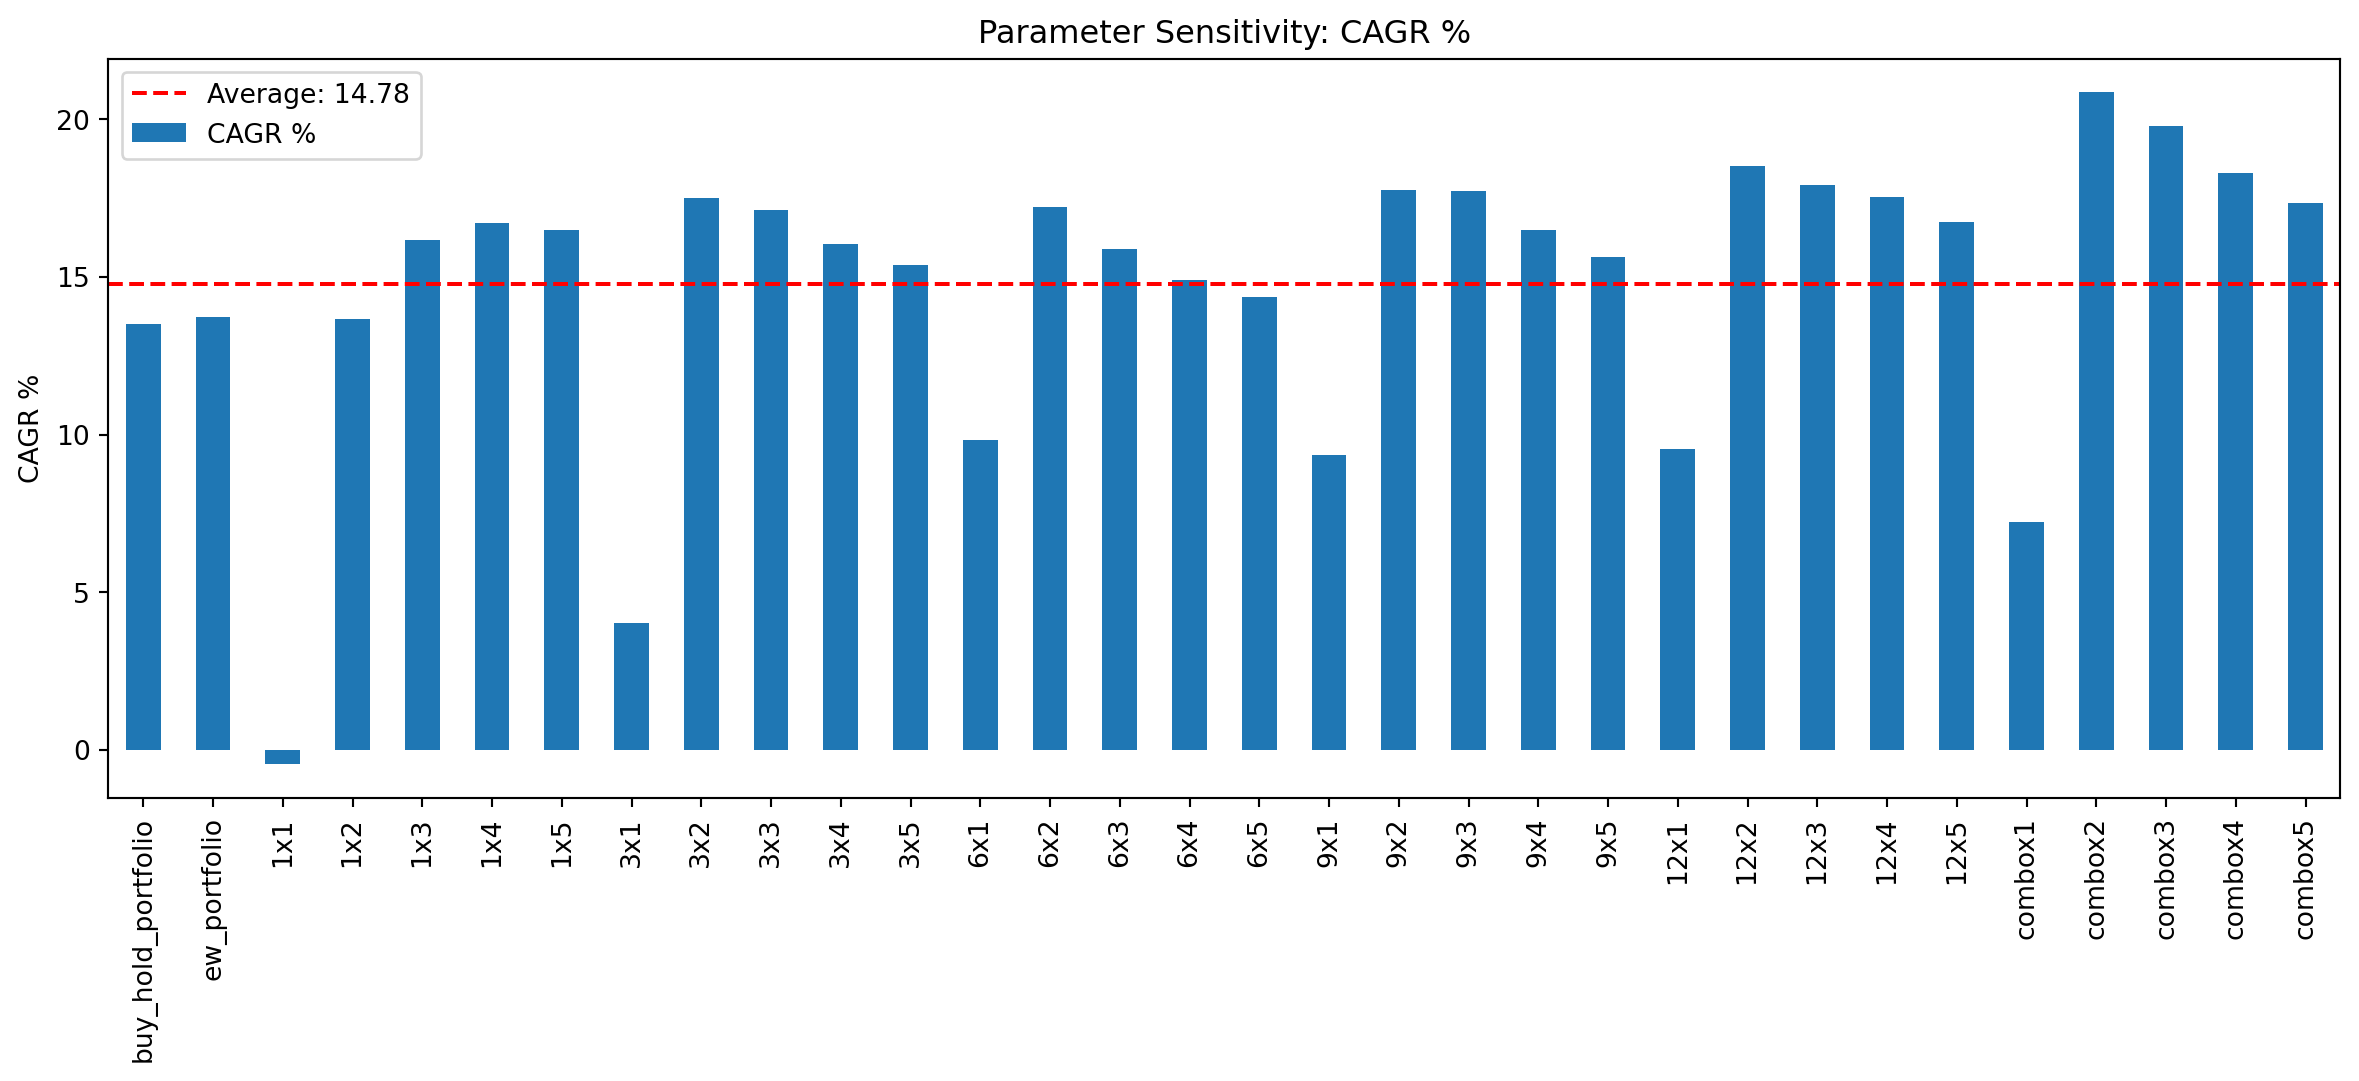

In [20]:
tools.parameter_sensitivity_bar_plot(strats_performance, 'CAGR %')

Portfolio concentration is a major driver of dispersion. Top1 portfolios have produced the worse results in each tested momentum formation period.

Excluding Top 1 and 1-month momentum formation period, the higher portfolio concentration has led to higher annualized returns in all lookbacks tested.

Outside Top1 and 1 Month ROC, all strategy variations were able to outperform the benchmark portfolios on a CAGR basis, suggesting that this TAA methodology is quite robust.

A clear pattern also emerges across lookback horizons: longer-term momentum signals tend to perform better. All ROC12 variants finish above the cross-sectional average CAGR.

The composite momentum has shown the best returns in every portfolio concentration variation (except Top1).

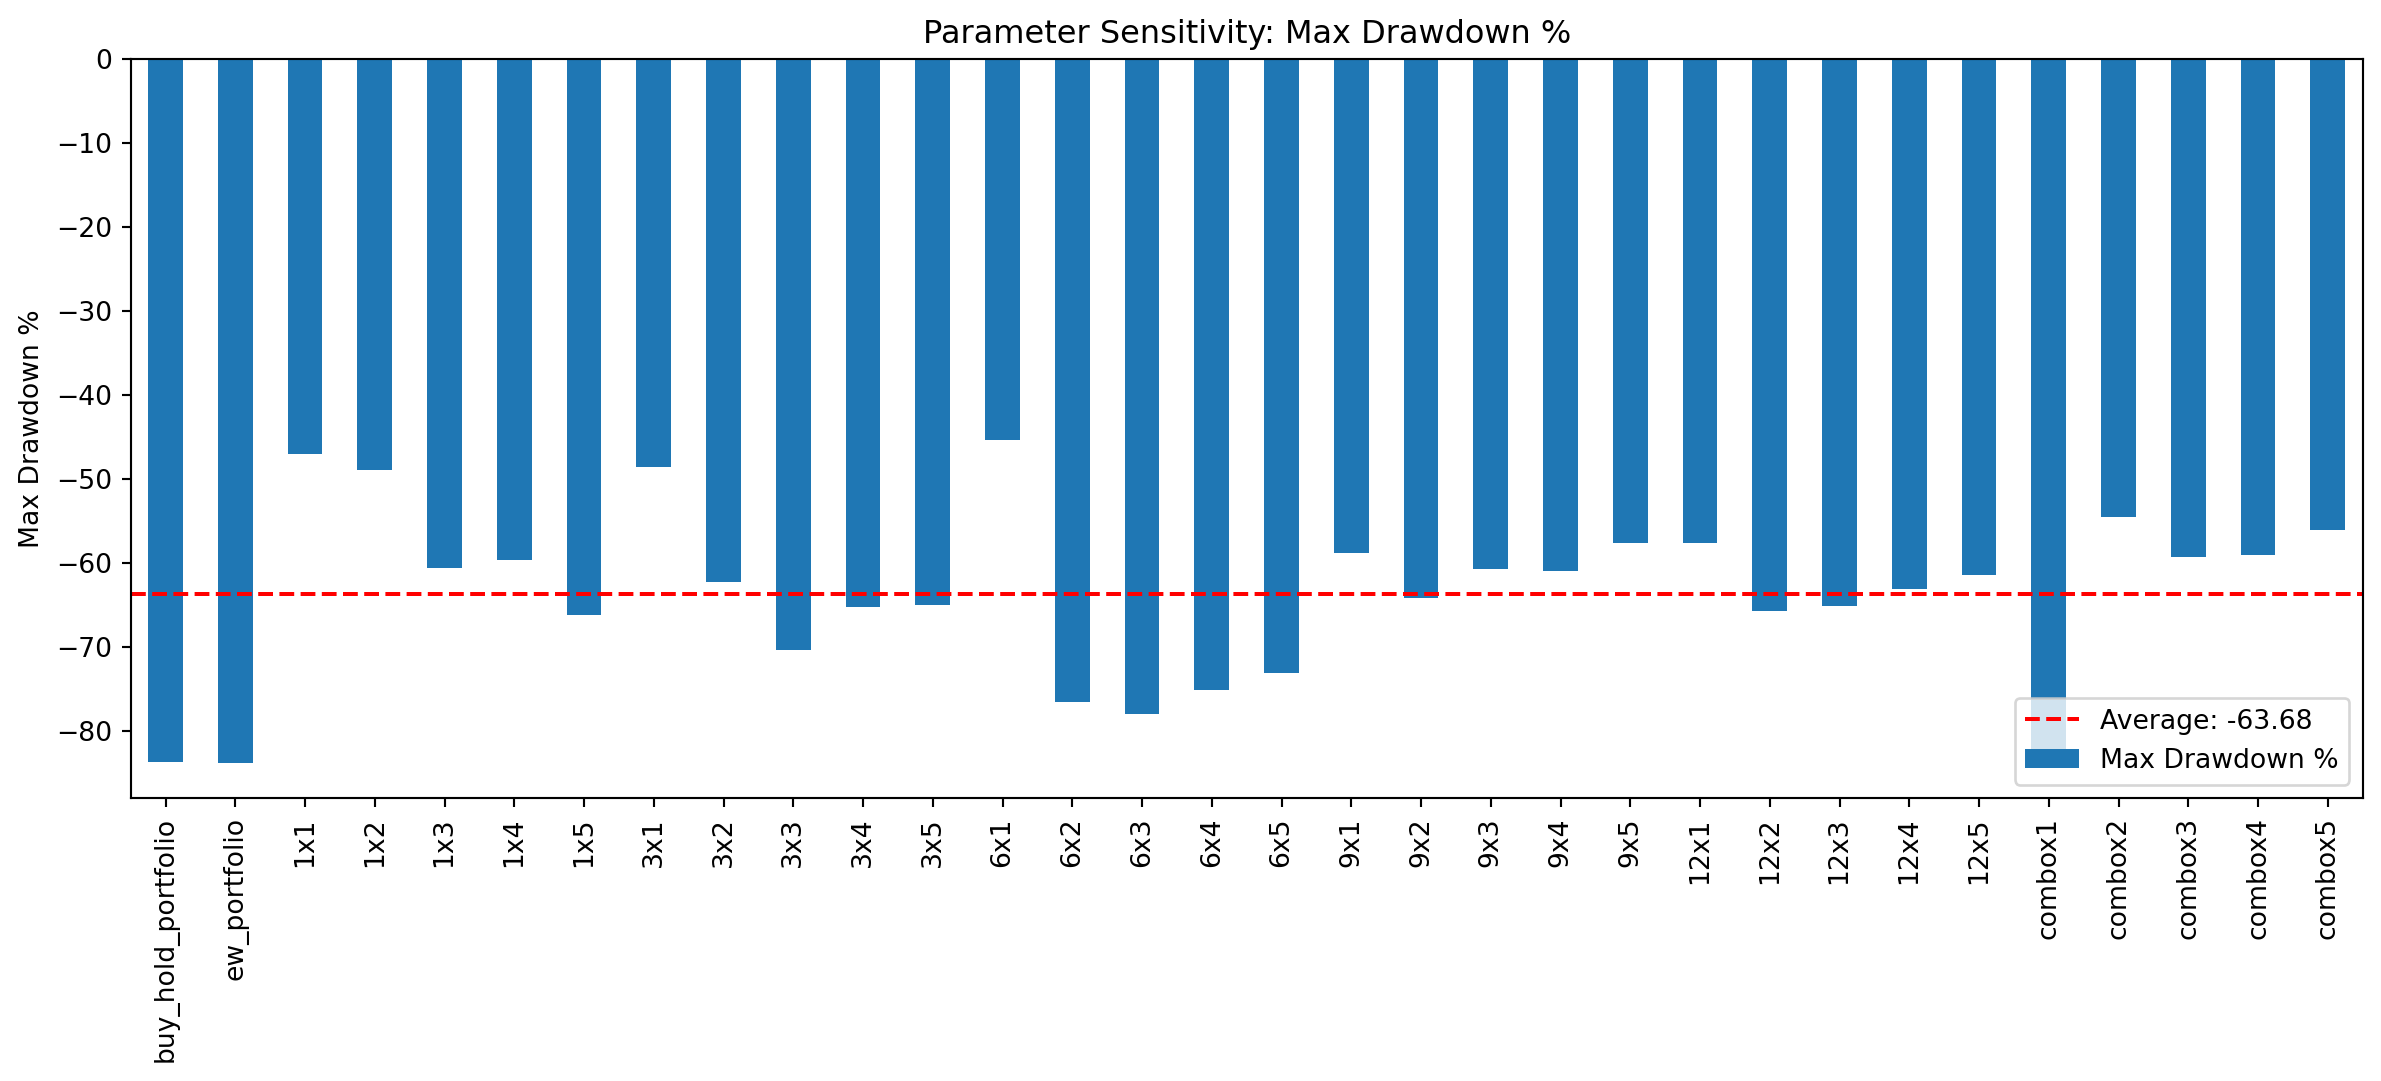

In [21]:
tools.parameter_sensitivity_bar_plot(strats_performance, 'Max Drawdown %')

Excluding only Composite Top1 model, all tested momentum configurations achieve lower maximum drawdowns than both benchmark portfolios, consistent with the defensive nature of trend-following strategies.

Unlike returns, however, drawdown behavior shows no clear relationship with portfolio concentration. Shorter lookbacks tend to benefit from higher concentration, while longer-term momentum configurations often experience deeper drawdowns as concentration increases.

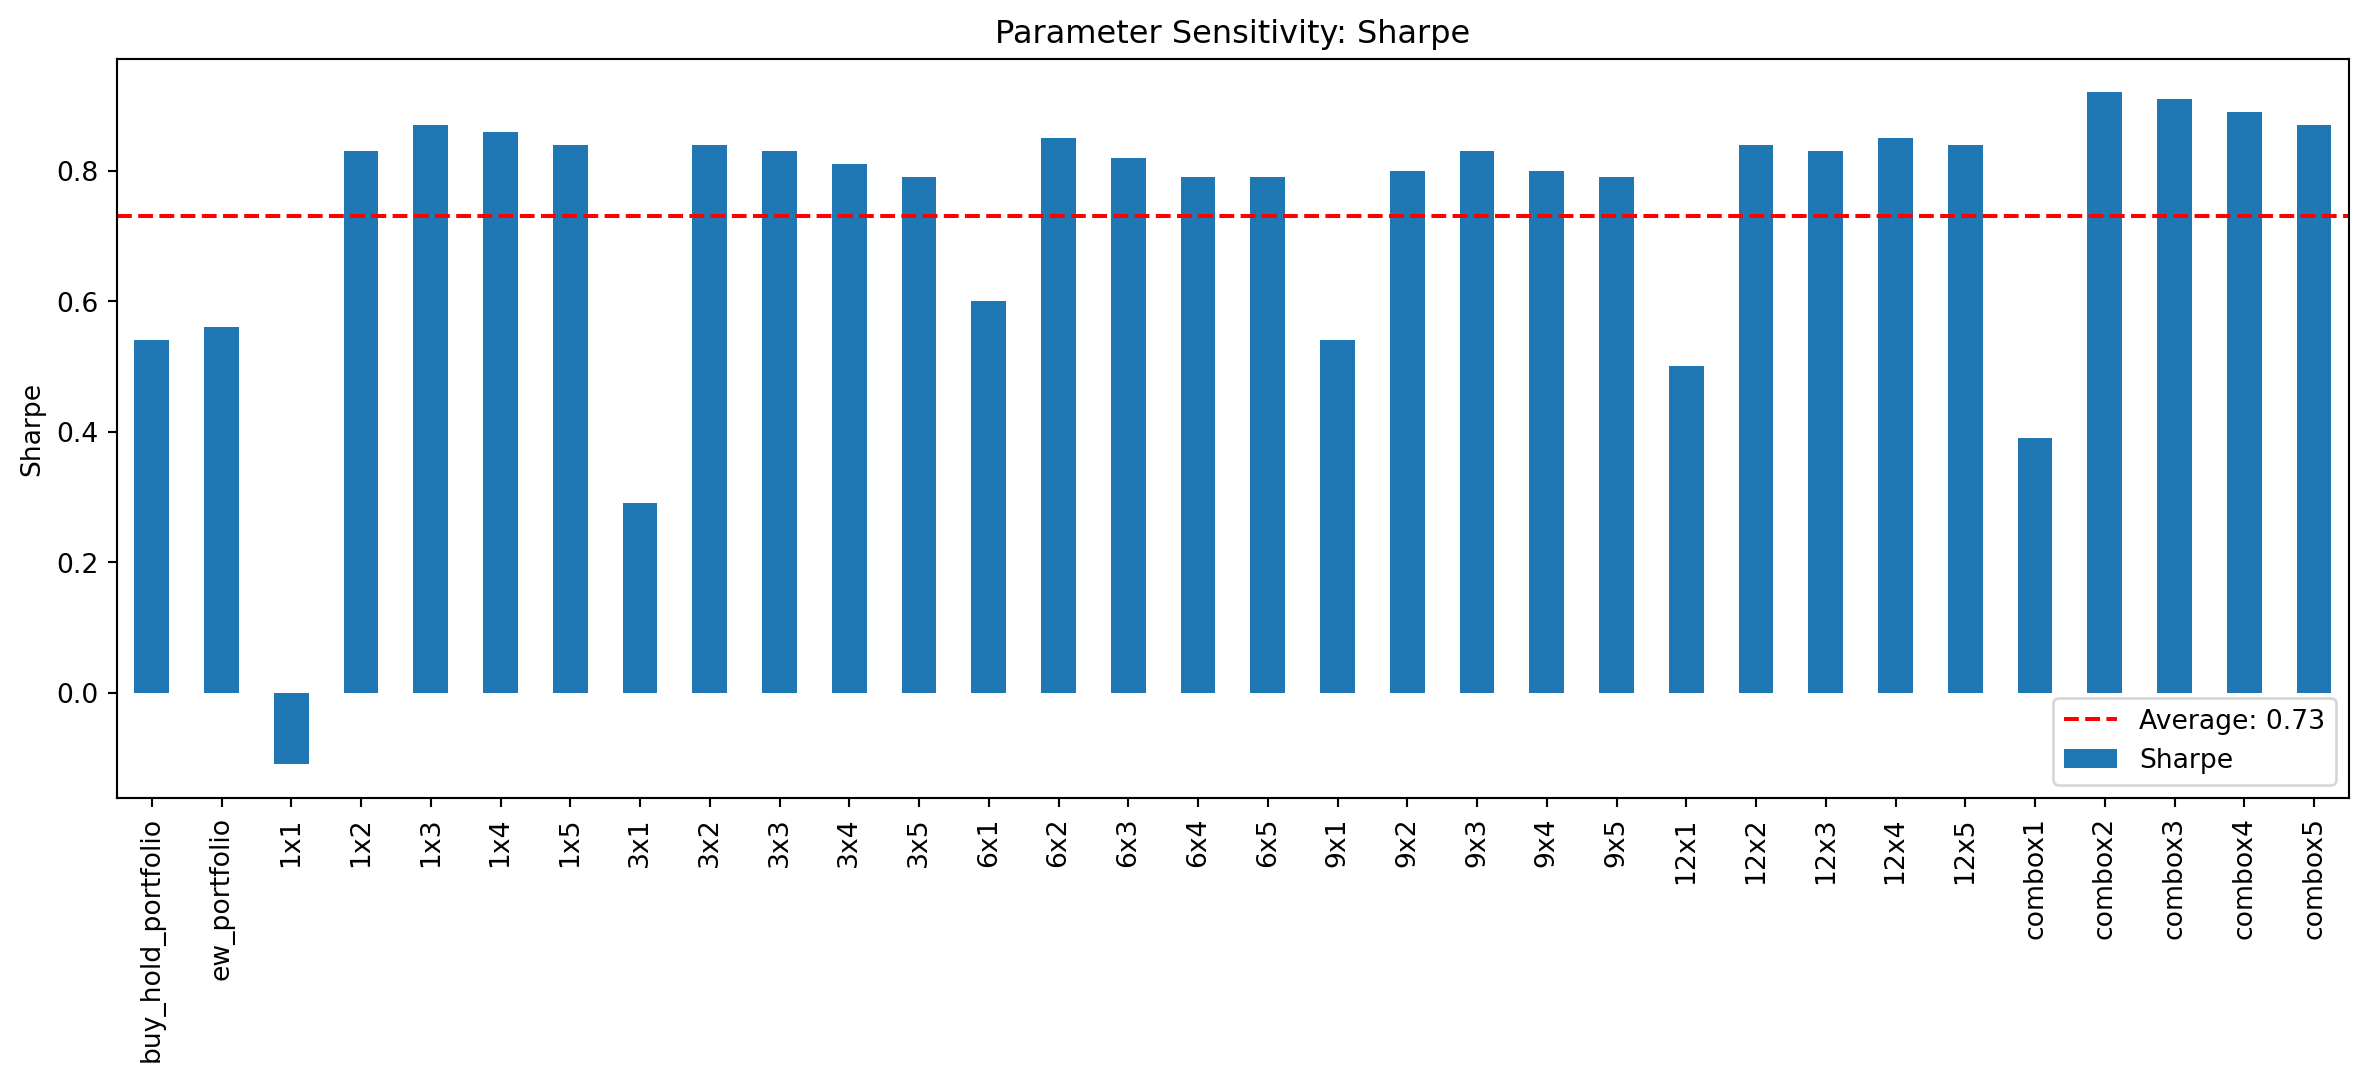

In [22]:
tools.parameter_sensitivity_bar_plot(strats_performance, 'Sharpe')

Outside Top1 variations, all have beaten both benchmarks in Risk Adjusted returns and have shown incredible consistency, prooving once again that this TAA staregy is robust accross different portfolio concentration and momentum formation periods.

#### Profit probability analysis

In [23]:
tools.metrics_time_window_analysis(bt_lookbacks, lookbacks=[6, 12, 24, 60, 120]).T

,6-month,12-month,24-month,60-month,120-month
buy_hold_portfolio,67.5%,71.1%,81.0%,90.5%,98.8%
ew_portfolio,69.4%,73.5%,83.7%,91.1%,99.3%
1x1,9.5%,16.1%,24.4%,26.7%,33.1%
1x2,70.9%,80.5%,87.0%,96.6%,100.0%
1x3,69.3%,79.8%,87.0%,96.2%,100.0%
1x4,69.5%,79.9%,88.2%,96.2%,100.0%
1x5,70.0%,79.9%,88.4%,96.2%,100.0%
3x1,44.1%,56.3%,67.8%,81.7%,92.6%
3x2,68.5%,75.1%,84.3%,92.7%,100.0%
3x3,69.1%,75.1%,84.8%,92.8%,100.0%


At every rolling period window there are several momentum configurations outperforming the EW portfolio in wealth preservation terms.

Consistent with previous data findings, none of the Top1 configurations manage to outperform the Equal-Weight benchmark over any of the tested rolling windows, highlighting the long-term fragility of highly concentrated portfolios. In contrast, several more diversified momentum variants achieve 100% profitable rolling 10-year periods.

#### Statistical Analysis

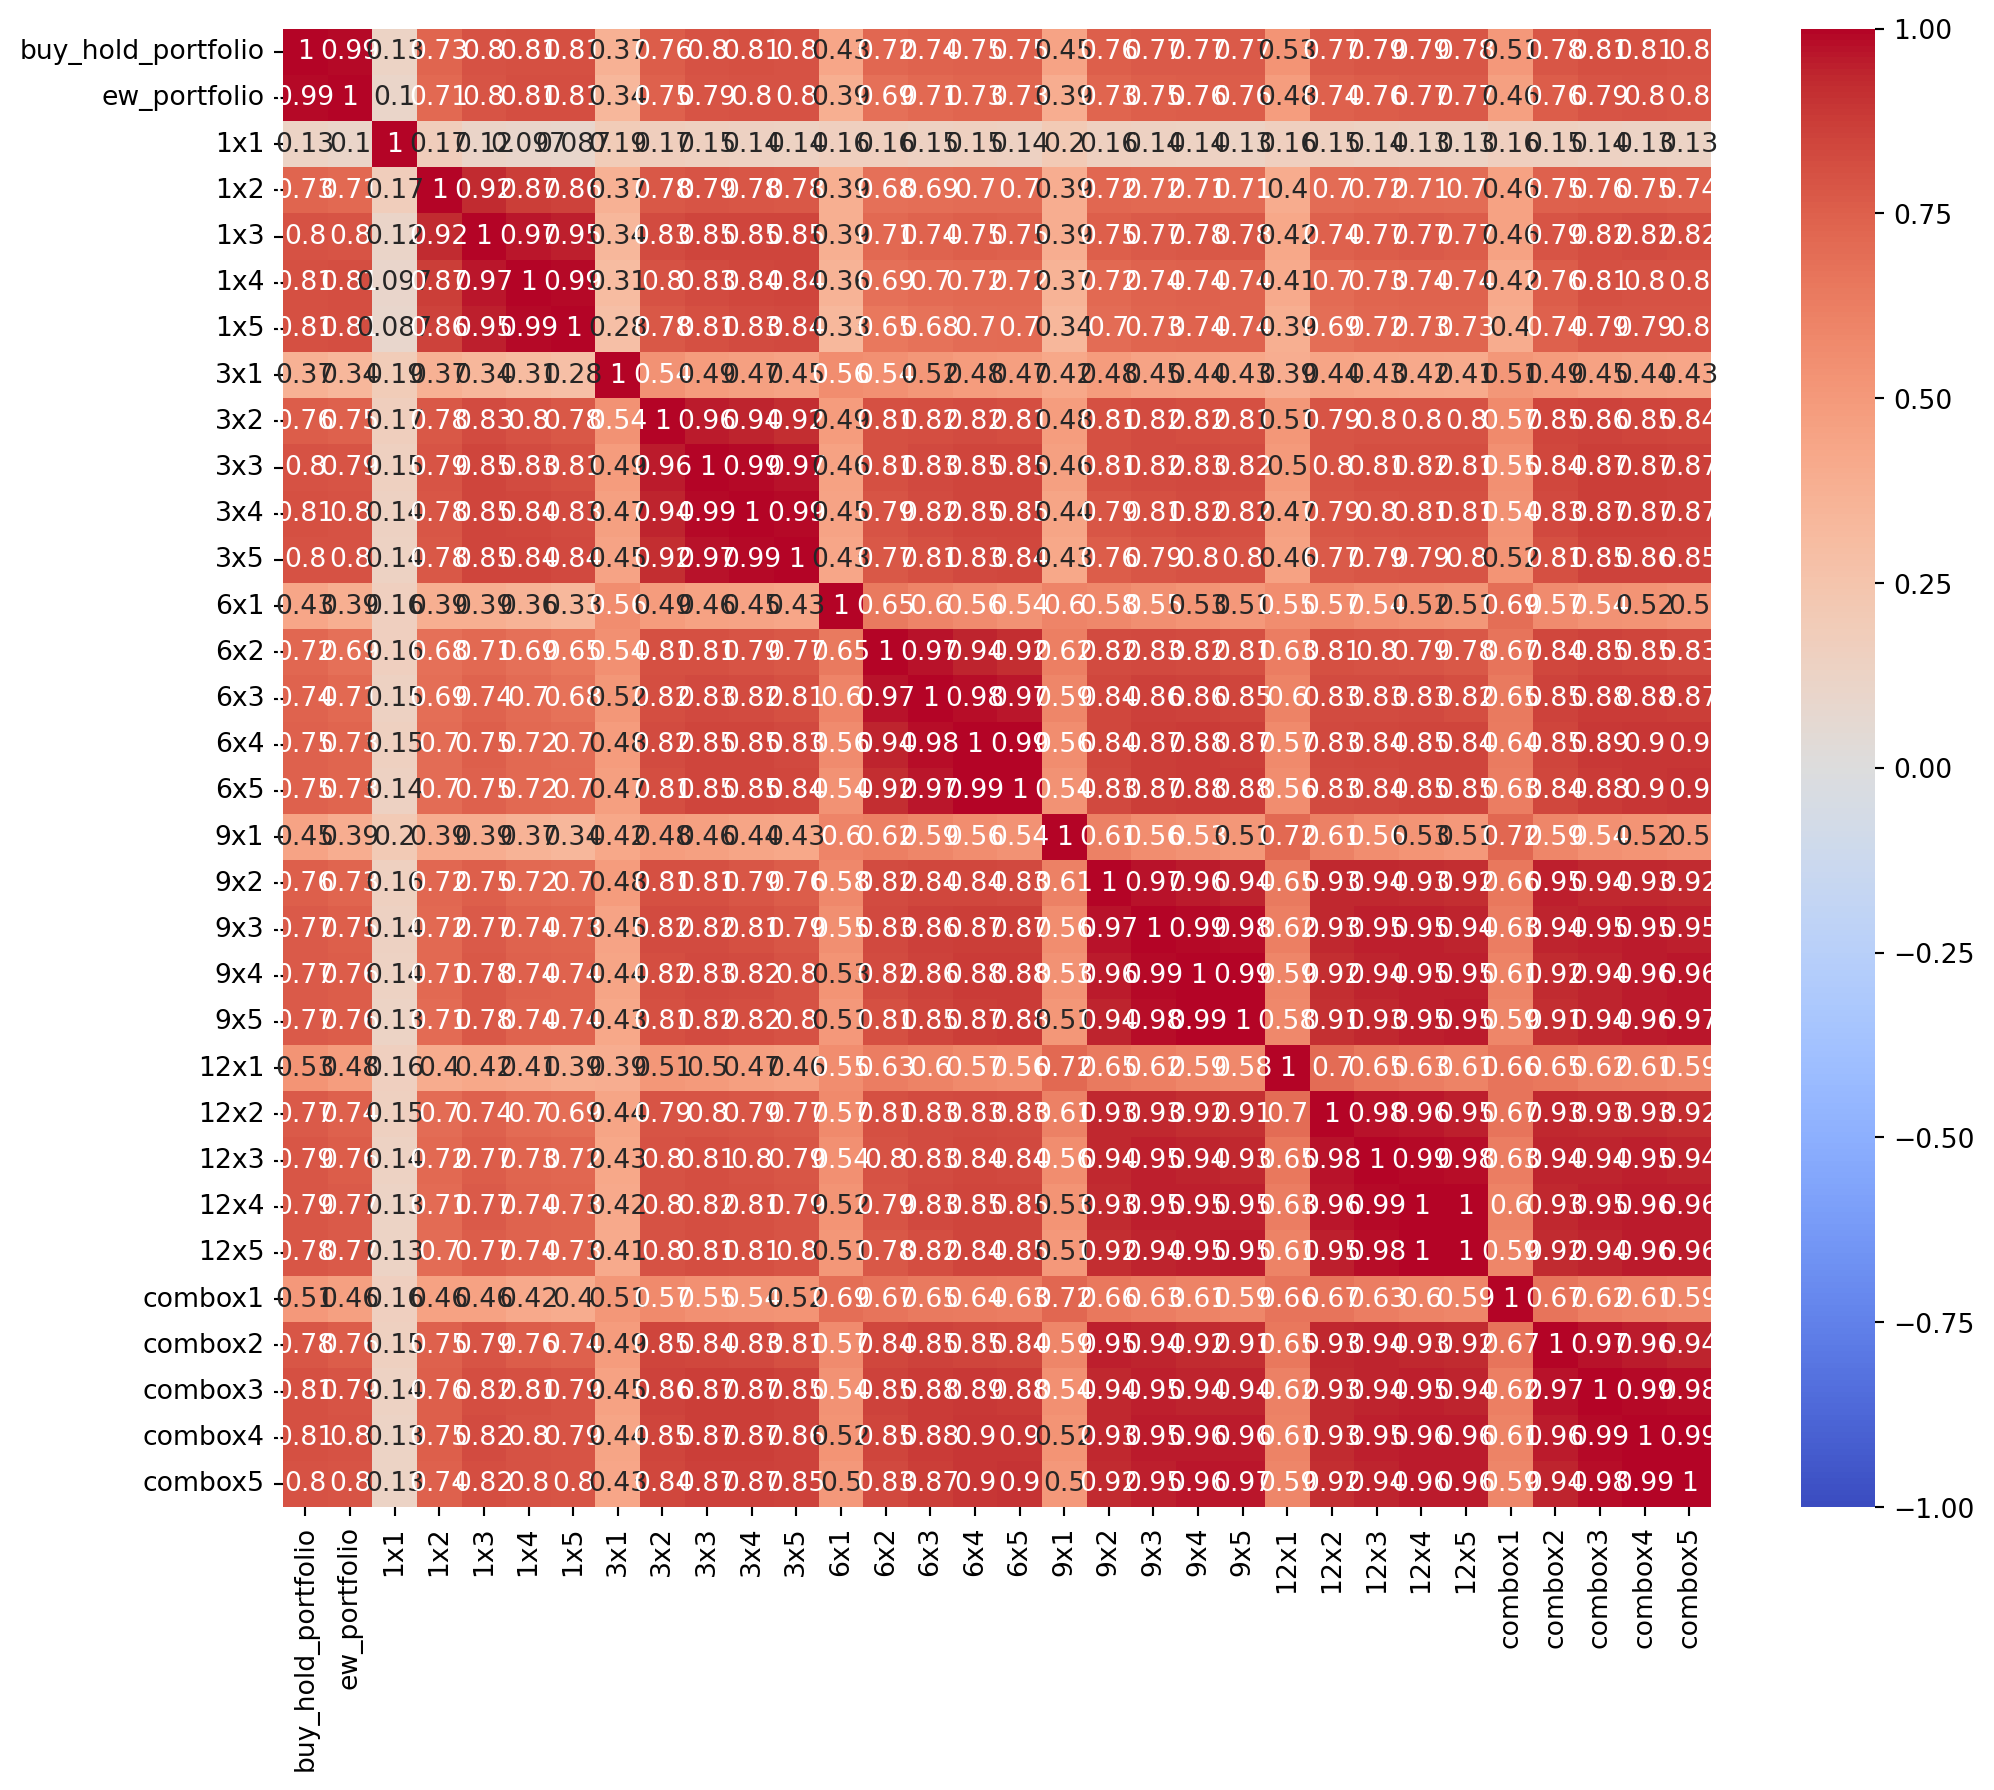

In [24]:
main.correlation_map(bt_lookbacks)

Longer-term momentum variants, particularly ROC9, ROC12, and the composite models, exhibit very high correlations (>0.9), indicating that they are largely capturing the same underlying slow-moving trend structure.

Within each lookback family, the different portfolio concentration variants are also highly correlated, especially outside the more concentrated Top1 implementations.

More broadly, most momentum configurations maintain correlations of about 0.7 versus both benchmark portfolios. This suggests that while the timing overlay improves certain portfolio characteristics, particularly returns and drawdowns, it does not fundamentally alter the underlying market exposure, with most strategy-to-benchmark correlations still remaining relatively high.

### Out-of-sample analysis

After identifying the most stable in-sample configuration, the next step is evaluating whether the observed momentum edge survives unseen market conditions.

For the out-of-sample evaluation, the ROC12 Top4 configuration was selected based on its strong in-sample robustness across multiple dimensions:

- ROC12 delivered above-average annualized returns across all portfolio concentrations (except Top1)

- The 12-month formation window is also the most extensively studied horizon in the momentum literature.

- ROC12 exhibited strong rolling return consistency across long investment horizons

- Performance remained stable across different concentration levels, suggesting limited parameter sensitivity.

- Within the ROC12 family, the Top4 configuration provided the most balanced trade-off between momentum concentration and diversification.


The out-of-sample period spans from July 2006 through March 2026, representing the final 20% of the available dataset.

In [25]:
os_backtest = bt.Backtest(SectorRotationStrategy, df_test, cash=100_000, commission=0.0)
os_result = os_backtest.run(roc_lookback=12, top_X=4, min_roc=0, close_on_last_bar=True)

os_benchmark = ew_portfolio.loc[os_result.returns.index]
os_benchmark.name = 'OS Benchmark'

main.plot_strategy_performance(os_result.returns, os_benchmark)

In the Out-of-sample period, both the Momentum strategy and the Equally-Weighted portfolio performed pretty similar in absolute returns terms.

The momentum strategy, however, delivered significantly lower volatility and much smaller drawdowns. During the Global Financial Crisis, its maximum drawdown was limited to -6.9%, versus nearly -60% for the benchmark. A similar pattern occurred during the 2020 COVID selloff, where momentum declined roughly -8.8% compared to a -32% correction in the Equally-Weighted portfolio.

These periods highlight the key strength of sector momentum rotation: the ability to avoid the weakest market segments during major equity downturns.

#### Returns Analysis

In [26]:
os_results = pd.concat([os_result.returns, os_benchmark], axis=1)

tools.strategy_performance_metrics(os_results, steps_per_year=12, rf=0)

,Strategy Backtest,OS Benchmark
CAGR %,7.65,7.36
Ann. Vola %,9.29,21.52
Max Drawdown %,-17.76,-60.96
VaR 5%,-4.01,-8.88
Time in Market %,92.37,100.00
Sharpe,0.82,0.34
Sortino,1.27,0.49
Calmar,0.43,0.12
Efficiency,0.08,0.07


As discussed previously, the strategy performed pretty similar to the benchmark in absolute return terms during the out-of-sample period.

However, it achieved those returns with substantially lower risk. The strategy reduced volatility by more than half and maximum drawdown by almost 3/4 , while more than doubling the Sharpe ratio relative to the benchmark.

Despite the slightly higher CAGR, the strategy demonstrates strong portfolio diversification value due to its significantly improved risk-adjusted profile.

In [27]:
tools.metrics_time_window_analysis(os_results, lookbacks=[6, 12, 24, 60, 120])

,Strategy Backtest,OS Benchmark
6-month,66.7%,60.6%
12-month,69.8%,60.4%
24-month,77.0%,68.1%
60-month,100.0%,98.3%
120-month,100.0%,100.0%


The momentum strategy proved consistently more reliable in wealth preservation terms, producing a higher percentage of profitable rolling period returns than the Equal-Weight benchmark in all tested lookbacks, from 6-month to 5-years.

Over 10-year rolling periods, both strategy and benchmark were profitable 100% of the time.

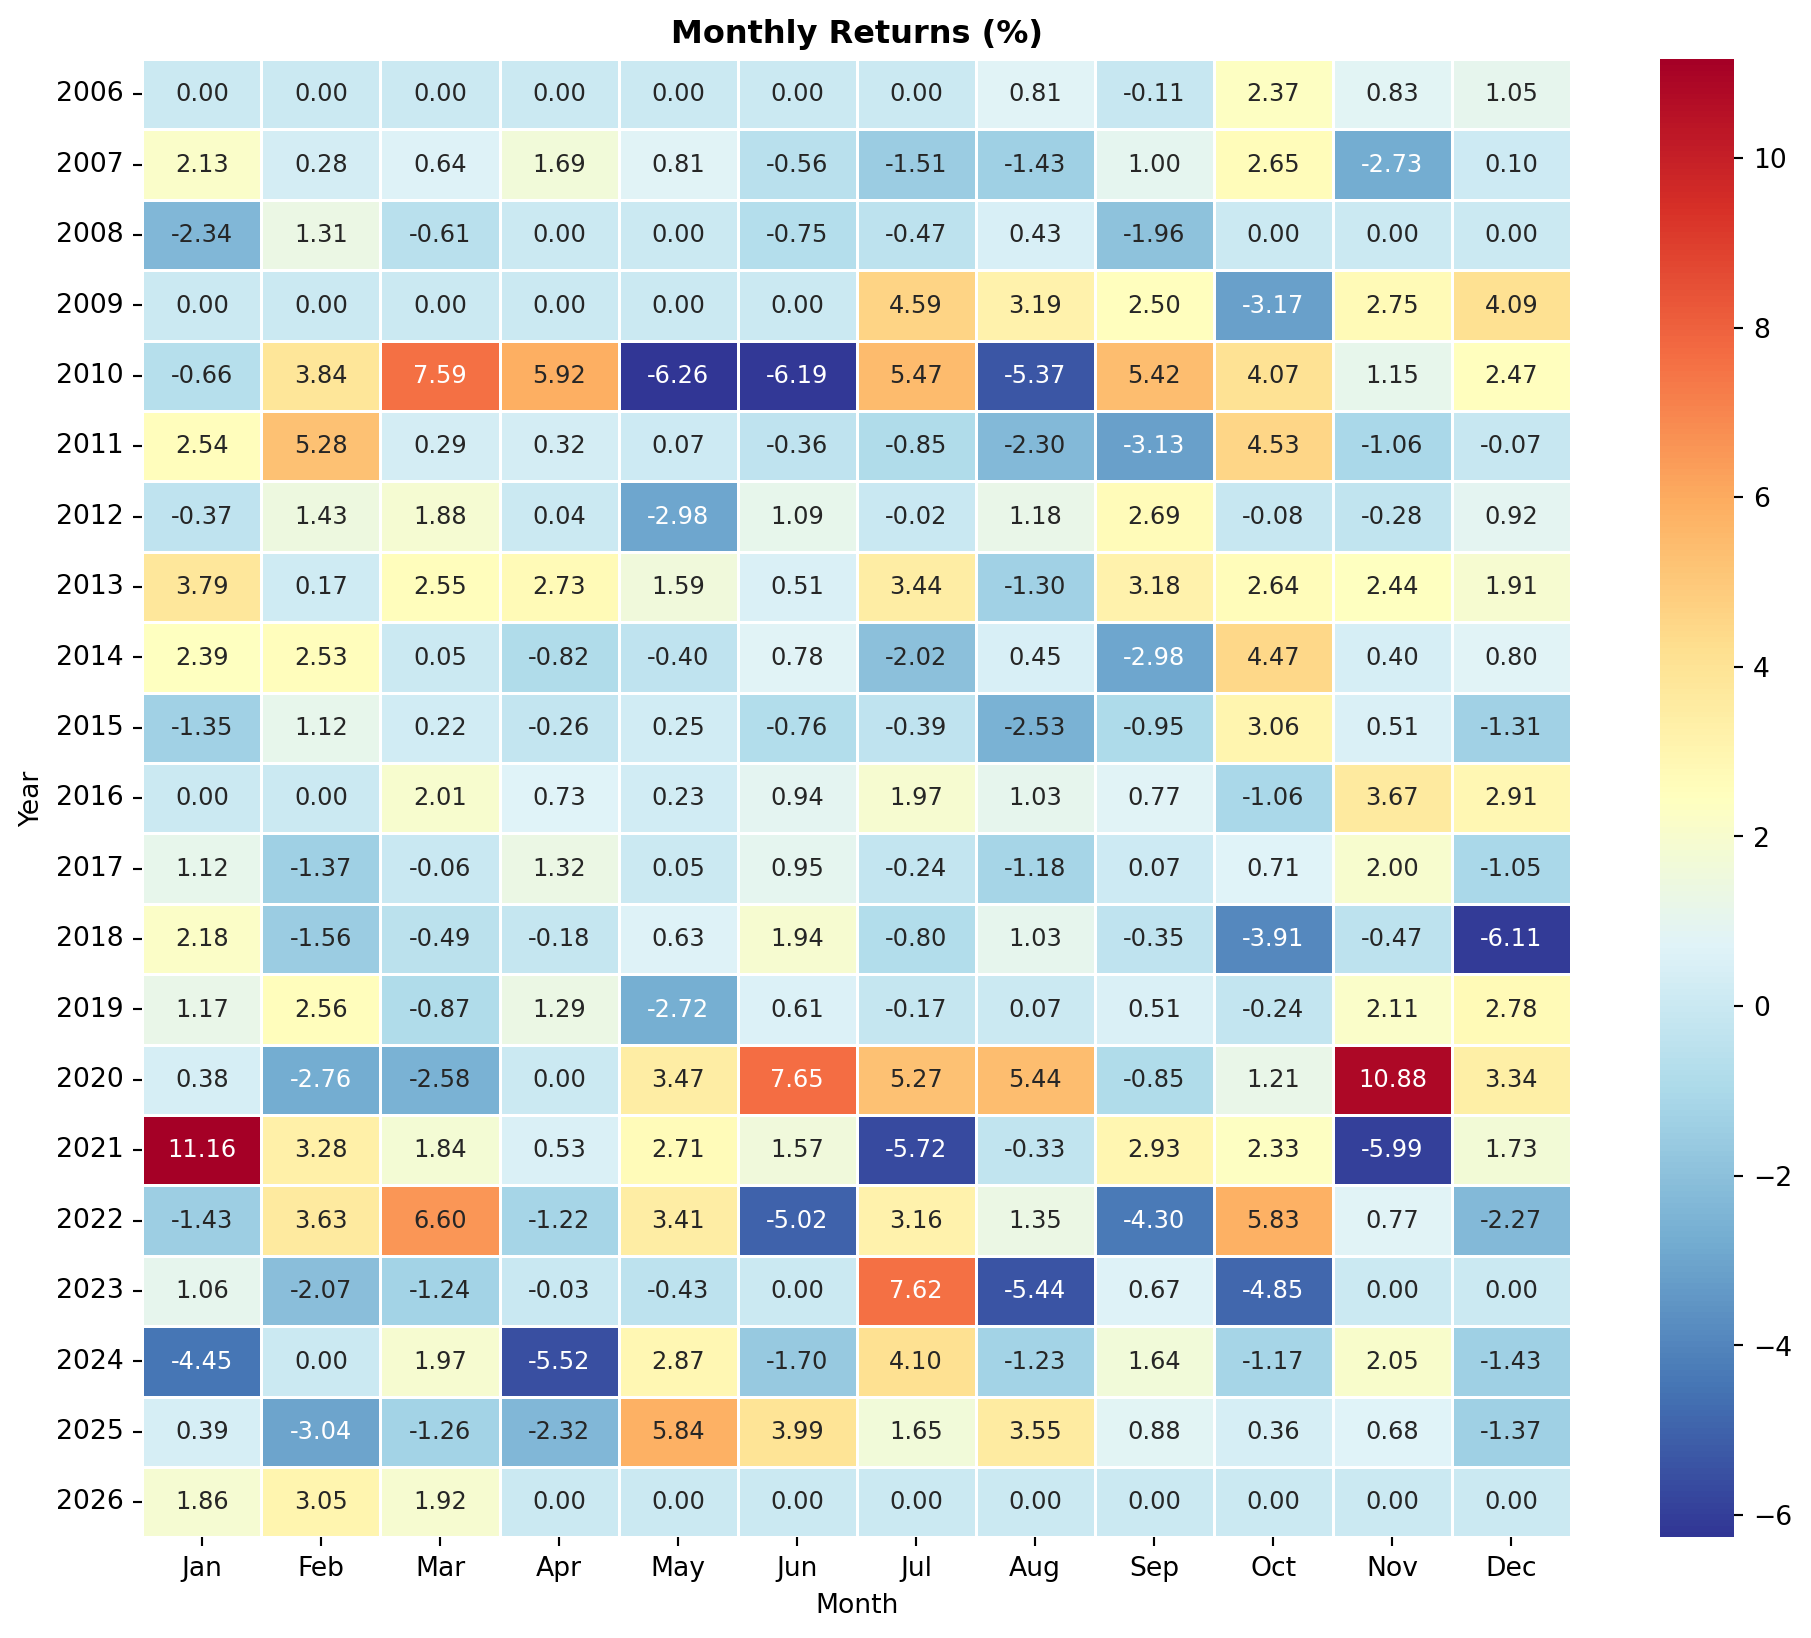

In [28]:
main.monthly_returns_heatmap(os_result.returns)

The strongest monthly return occurred in January 2021, when the strategy gained 11.2%.

The weakest month was May 2010, with a decline of roughly -6.3%.

#### Trades Analysis

In [29]:
os_result.trades

,symbol,open_date,close_date,bars_held,open_price,close_price,position_size,profit_loss,change_pct,trade_commission,cumulative_return,why_exit
0,HiTec,2006-07-01,2006-08-01,1,35340.92,33446.65,0.71,-1340.00,-5.36,0.00,98660.00,Dropped Top4
1,Hlth,2006-07-01,2006-08-01,1,50631.98,48287.72,0.49,-1157.50,-4.63,0.00,97502.50,Dropped Top4
2,Utils,2006-08-01,2006-09-01,1,7823.01,7815.93,1.00,-7.09,-0.09,0.00,97495.41,Rebalancing
3,Other,2006-08-01,2006-09-01,1,27918.00,28724.90,0.87,704.52,2.89,0.00,98199.93,Rebalancing
4,Utils,2006-08-01,2006-10-01,3,7823.01,7815.93,2.12,-15.00,-0.09,0.00,98184.93,Dropped Top4
...,...,...,...,...,...,...,...,...,...,...,...,...
213,Enrgy,2026-02-01,2026-03-01,1,36979.58,44094.94,1.00,7115.36,19.24,0.00,385222.63,Rebalancing
214,Manuf,2026-02-01,2026-03-01,1,154346.68,150937.53,0.64,-2186.46,-2.21,0.00,383036.18,Rebalancing
215,Utils,2024-07-01,2026-03-01,22,45012.75,66824.97,0.90,19636.72,48.46,0.00,402672.90,Close on Last Bar
216,Telcm,2025-09-01,2026-03-01,8,80539.38,87019.78,0.20,1297.47,8.05,0.00,403970.36,Close on Last Bar


In [30]:
signals_trades = os_result.trades[os_result.trades['why_exit'] != 'Rebalancing']

tools.metrics_trades(signals_trades, full_metrics=True)

,Trades Analysis
Nr trades,115.00
Win Rate %,49.57
Profit Factor,2.08
Avg. Win %,17.36
Avg. Loss %,-4.85
Reward/Risk,3.58
Expectancy %,6.16
Avg. Bars Held,5.00
Commissions,0.00
Max Bars Held,23.00


During the out-of-sample period, the strategy generated 114 signal driven trades, averaging roughly 5 trades per year. The longest position was held for 23 months, while the average holding period was approximately 5 months.

Winning trades accounted for 50% of all positions. The best trade returned 172%, compared to a worst trade loss of -20%, with average winners approximately 3.5x larger than average losers.

In practical terms, the strategy extracted roughly 6.3% profit per signal generated throughout the OOS period.

In [31]:
# rebalancing_trades = os_result.trades[os_result.trades['why_exit'] == 'Rebalancing']

# tools.metrics_trades(rebalancing_trades)

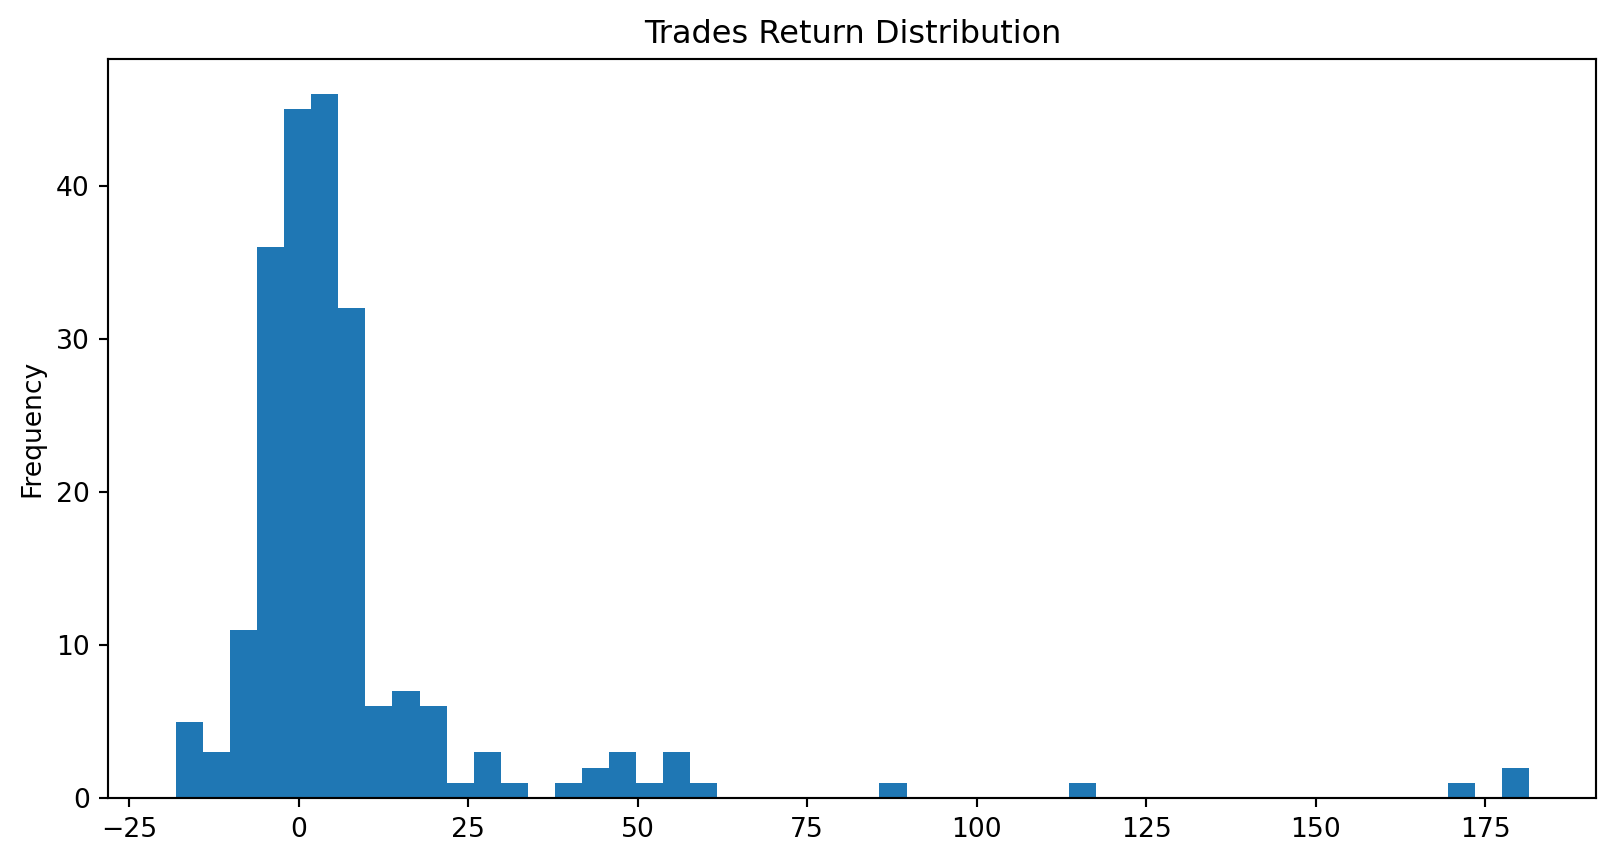

In [32]:
clipped_returns = main.cap_series(os_result.trades['change_pct'], percentile=0.005)
ax1 = clipped_returns.plot.hist(bins=50, title="Trades Return Distribution", figsize=(10, 5))

There is a high concentration of trades that returned near 0 returns on the downside and some trades that delivered exceptional returns on the upside, meaning that the momentum overlay is working as intended, **cutting losses short and letting profits run**.

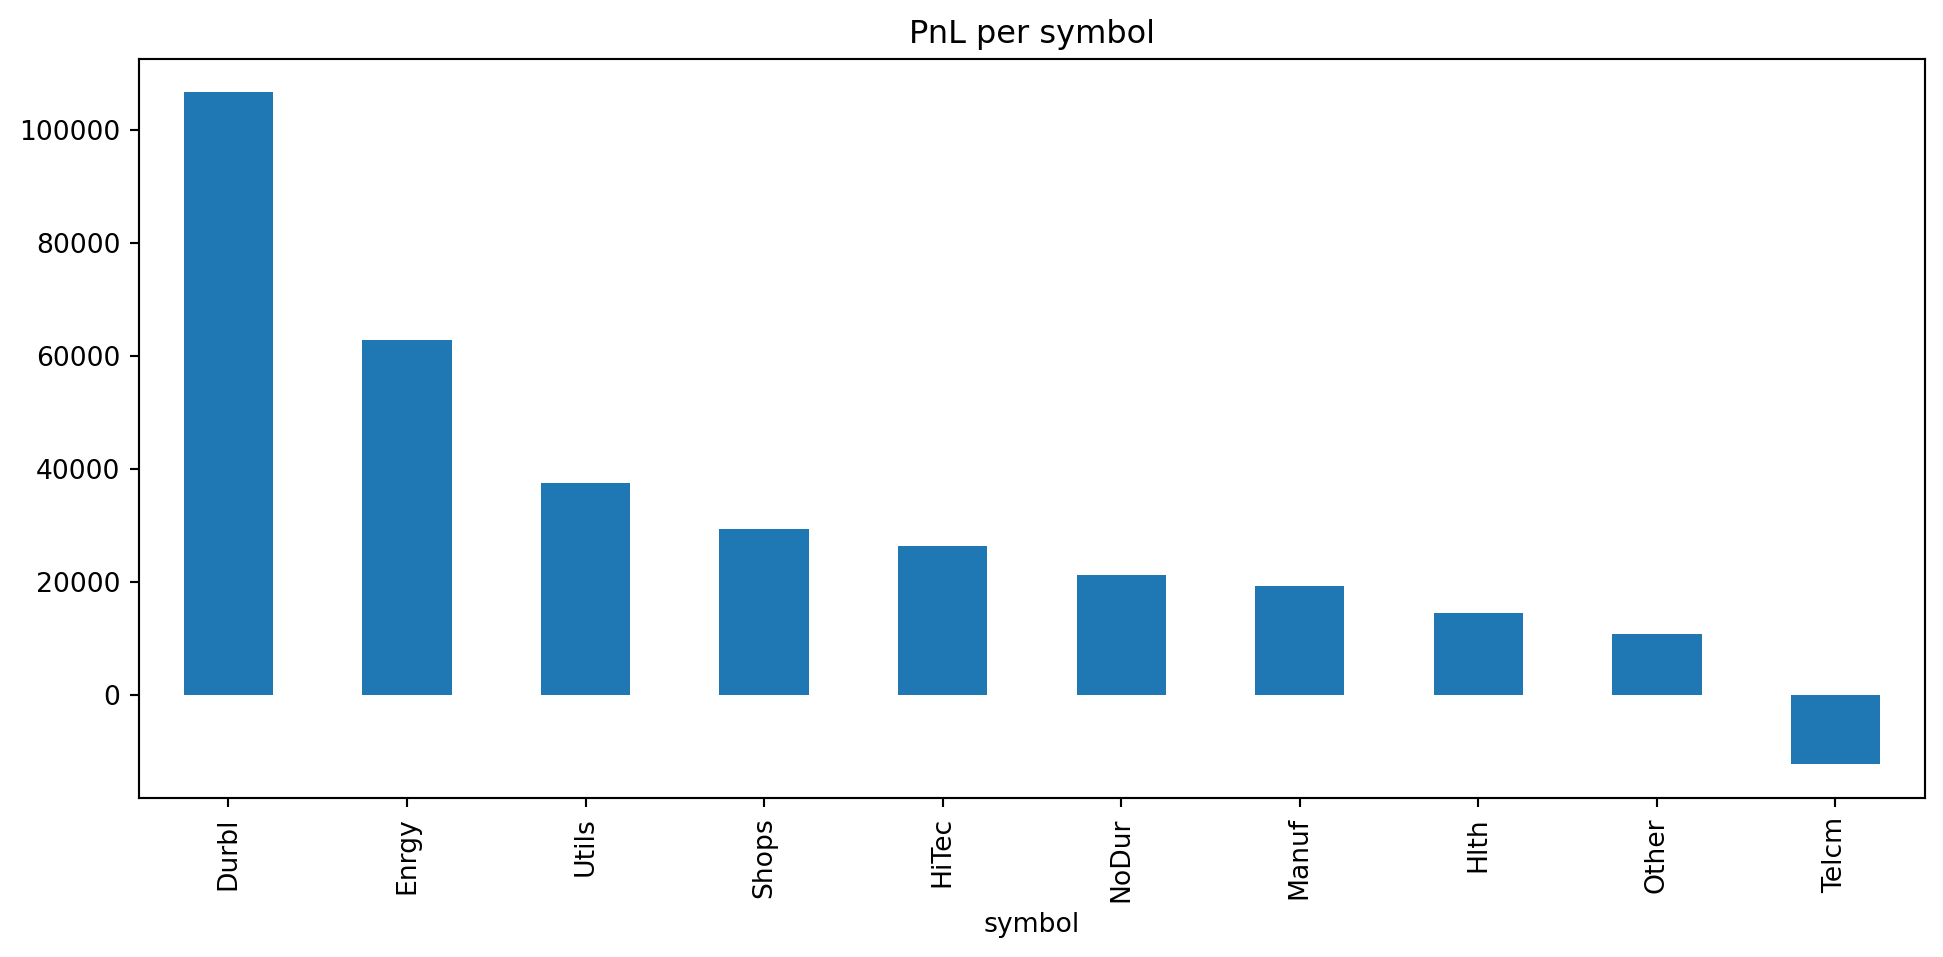

In [33]:
pnl_per_symbol = (
    os_result.trades
    .groupby("symbol")["profit_loss"]
    .sum()
    ).sort_values(ascending=False)

ax7 = pnl_per_symbol.plot.bar(title='PnL per symbol', figsize=(12,5))

Durables and Energy were the strongest contributors to overall portfolio profits, generating substantially higher PnL than the remaining sectors.

Only Telecom sector has finished with negative cumulative contribution over the out-of-sample period.


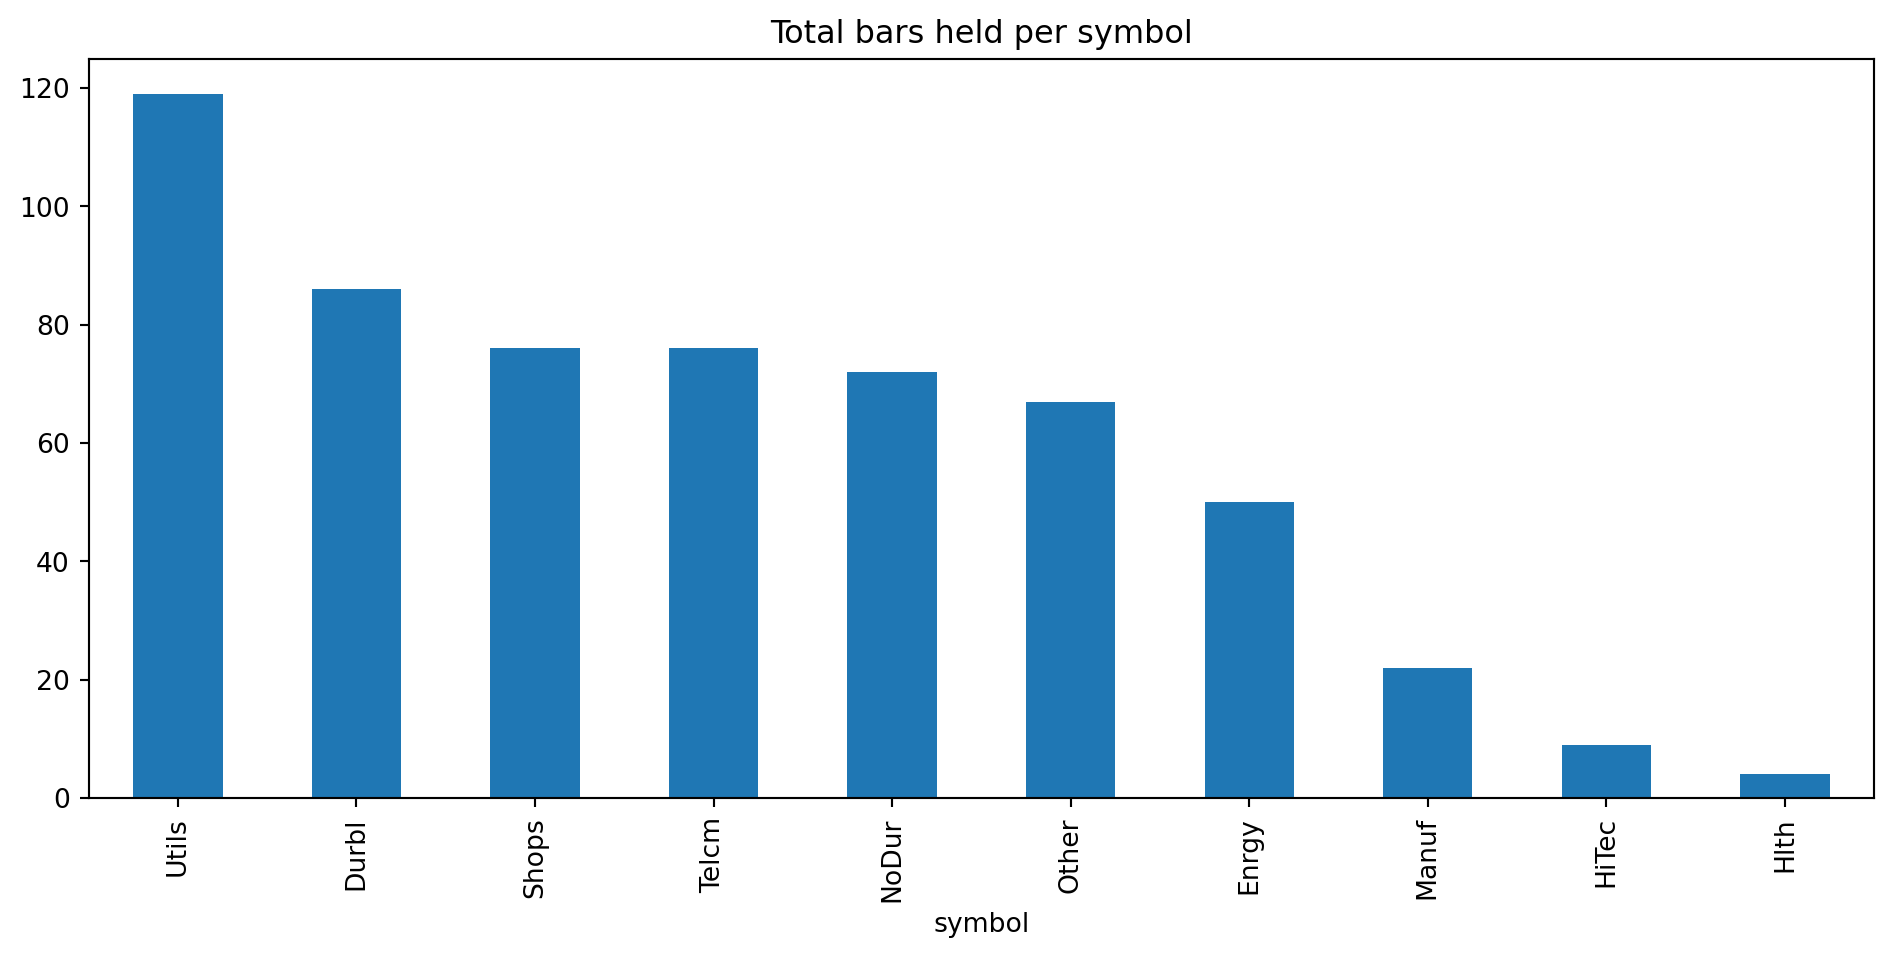

In [34]:
bars_per_symbol = (
    signals_trades
    .groupby("symbol")["bars_held"]
    .sum()
).sort_values(ascending=False)

ax4 = bars_per_symbol.plot.bar(title='Total bars held per symbol', figsize=(12,5))

Utilities were the most persistent sector exposure, remaining in the portfolio for more than half of the out-of-sample period (120 out of 236 months).

At the opposite extreme, both Healthcare and High-Tech had pretty low exposure, indicating that they rarely ranked among the strongest momentum sectors during the sample.

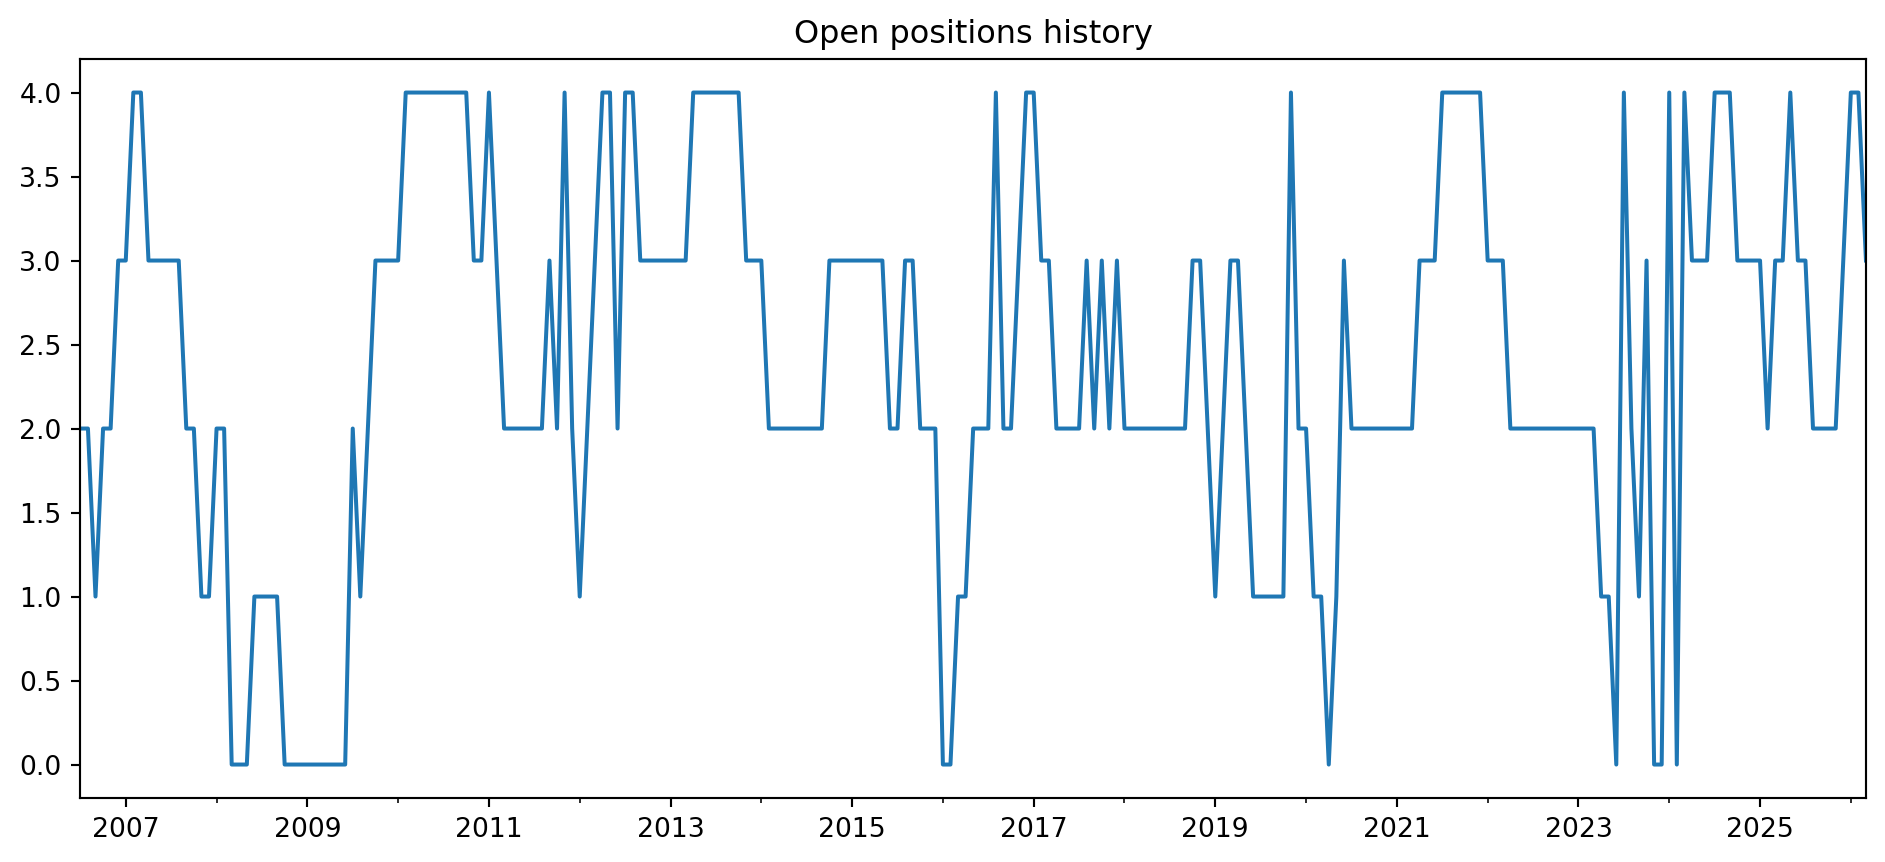

In [35]:
ax9 = os_result.open_positions_history.plot(title='Open positions history', figsize=(12,5))

In [36]:
os_result.open_positions_history.describe()

count   237.00
mean      2.39
std       1.13
min       0.00
25%       2.00
50%       2.00
75%       3.00
max       4.00
Name: Strategy Open Positions, dtype: float64

There were some occasions (2009 GFC) where portfolio was sitting entirely on cash, as the positive Momentum threshold prevented buying sectors with negative return in the chosen lookback.

On average there were 2.4 open positions each month for the sample period. Due to the positive momentum threshold in very few occasions there were 4 open positions as apparently for much of the period rarely existed 4 positive momentum industry sectors.

In [37]:
# parked_cash_pct = (os_result.parked_cash/os_result.returns)*100
# # invested_capital_pct = 100-parked_cash_pct

# ax10 = parked_cash_pct.plot(title='Parked cash history (%)', figsize=(12,5))

In [38]:
import plotly.express as px

ax5 = px.scatter(
    signals_trades, 
    x='bars_held',
    y='change_pct',
    width=900,
    height=500,
    trendline="ols",
    trendline_color_override="black",
    title='Trade duration VS Trade Profit',
    template='seaborn'
)

ax5.show()

The chart suggests a positive relationship between trade duration and profitability, with longer-held trades generally producing higher returns.

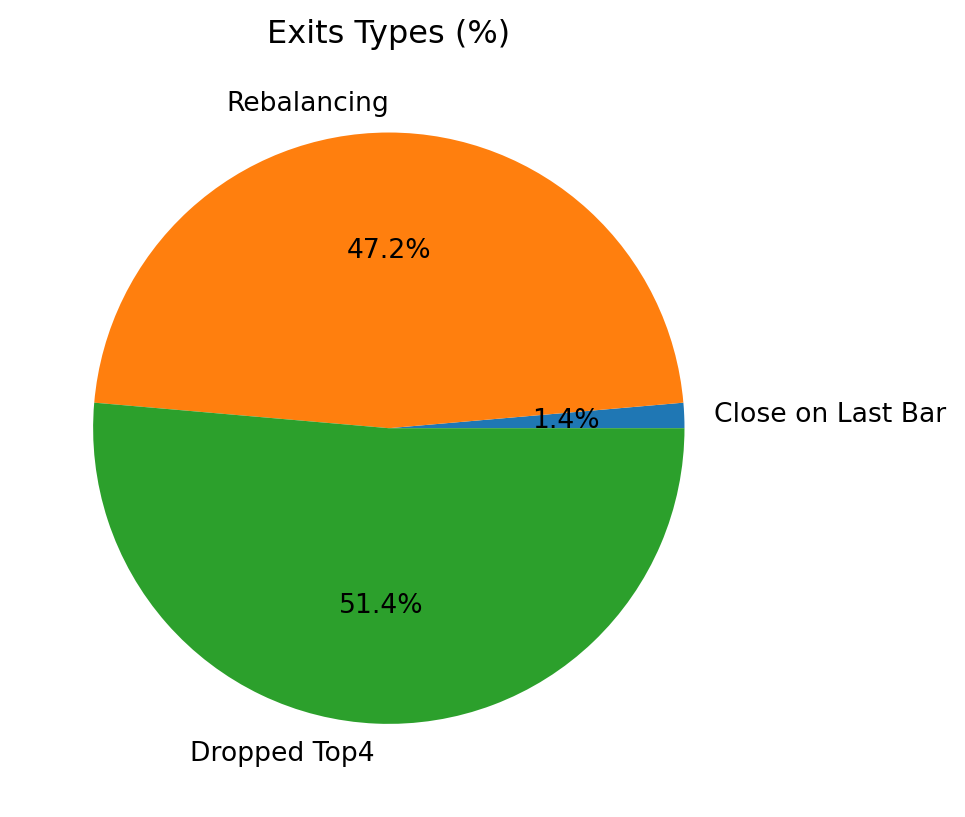

In [39]:
exit_types_df = (
    (os_result.trades
    .groupby(['why_exit'])
    .size()/len(os_result.trades))*100
    ).sort_values()

ax6 = exit_types_df.plot.pie(title='Exits Types (%)', figsize=(10,5), autopct='%1.1f%%')

Nearly 51% of sell trades are related to rebalancing due to overperformance, rebalacing threshold was 0%, so whenever any asset deviated slightly from its portfolio target weight got trimmed back to 25% allocation, aiming for an equal weighted portfolio.

##### Trades signals for a Symbol

In [40]:
symbol = 'Durbl'

symbol_trades = signals_trades[signals_trades['symbol'] == symbol]
symbol_trades

,symbol,open_date,close_date,bars_held,open_price,close_price,position_size,profit_loss,change_pct,trade_commission,cumulative_return,why_exit
13,Durbl,2007-02-01,2007-04-01,3,4300.67,4261.25,5.08,-200.29,-0.92,0.00,103347.46,Dropped Top4
19,Durbl,2007-08-01,2007-10-01,2,4246.33,4121.92,6.24,-776.28,-2.93,0.00,105449.69,Dropped Top4
40,Durbl,2009-11-01,2011-02-01,18,2653.15,4090.80,7.18,10323.72,54.19,0.00,130023.81,Dropped Top4
64,Durbl,2013-01-01,2013-02-01,1,3828.52,4178.83,9.81,3437.21,9.15,0.00,151837.45,Dropped Top4
75,Durbl,2013-06-01,2014-04-01,11,4784.92,6159.17,7.74,10629.87,28.72,0.00,196440.57,Dropped Top4
78,Durbl,2014-06-01,2014-07-01,1,5955.50,6121.66,8.26,1372.58,2.79,0.00,195555.27,Dropped Top4
83,Durbl,2014-09-01,2015-01-01,4,6496.71,6353.12,7.51,-1078.61,-2.21,0.00,196533.17,Dropped Top4
88,Durbl,2015-03-01,2015-06-01,4,6493.99,6435.53,6.69,-391.04,-0.90,0.00,197022.50,Dropped Top4
108,Durbl,2016-10-01,2017-01-01,4,6745.38,7306.83,6.81,3823.85,8.32,0.00,211173.12,Dropped Top4
113,Durbl,2017-02-01,2017-03-01,1,7097.12,7085.76,7.92,-89.98,-0.16,0.00,222585.47,Dropped Top4


In [41]:
tools.plot_trades_signals(df_test[symbol][['Close']], symbol_trades)

This graph helps visualize the high agility offered by a momentum overlay.

Sector rotation strategy added "Durables" to the portfolio on August 2007 and removed it just 2 months later on October 2007, just before a huge -75% Draw down.

It entered again in November 2009, just up until the same level it got out in 2007, in February 2011 returning 47%, in practical terms, a buy and hold investor during this time has just got back even, 2 years after, while getting a -75% Maximum Drawdown. The smart sector rotation investor has avoided the crash and has even gained a 47% profit in the same period in the same asset.

##### Is it significantly different from 0?

In [42]:
main.compute_t_test(os_result.returns)

P-value: 0.00023611590683381942 Reject the null hypothesis (H₀). The strategy average return is significantly different from zero.


##### Does it pass Monte Carlo Permutation?

This will shuffle the given equity curve returns in random order, all output equity curves start and end at the same place, only the path will vary, to obtain Confidence Intervals for Maximum Draw Down Figures.

In [43]:
#| code-fold: show

mcpyt = main.monte_carlo_permutation_yt(os_result.returns, nr_simulations=1000)
mcpyt.tail(3)

,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
2026-01-01,4.28,3.94,4.07,4.08,3.95,3.89,4.17,4.08,4.27,3.97,...,4.30,4.19,4.67,4.08,4.22,4.09,4.22,4.15,4.13,4.50
2026-02-01,4.27,4.12,4.20,4.13,3.96,4.32,4.28,4.16,4.26,4.17,...,4.32,4.19,4.52,4.10,4.30,4.24,4.22,4.36,4.18,4.52
2026-03-01,4.27,4.27,4.27,4.27,4.27,4.27,4.27,4.27,4.27,4.27,...,4.27,4.27,4.27,4.27,4.27,4.27,4.27,4.27,4.27,4.27


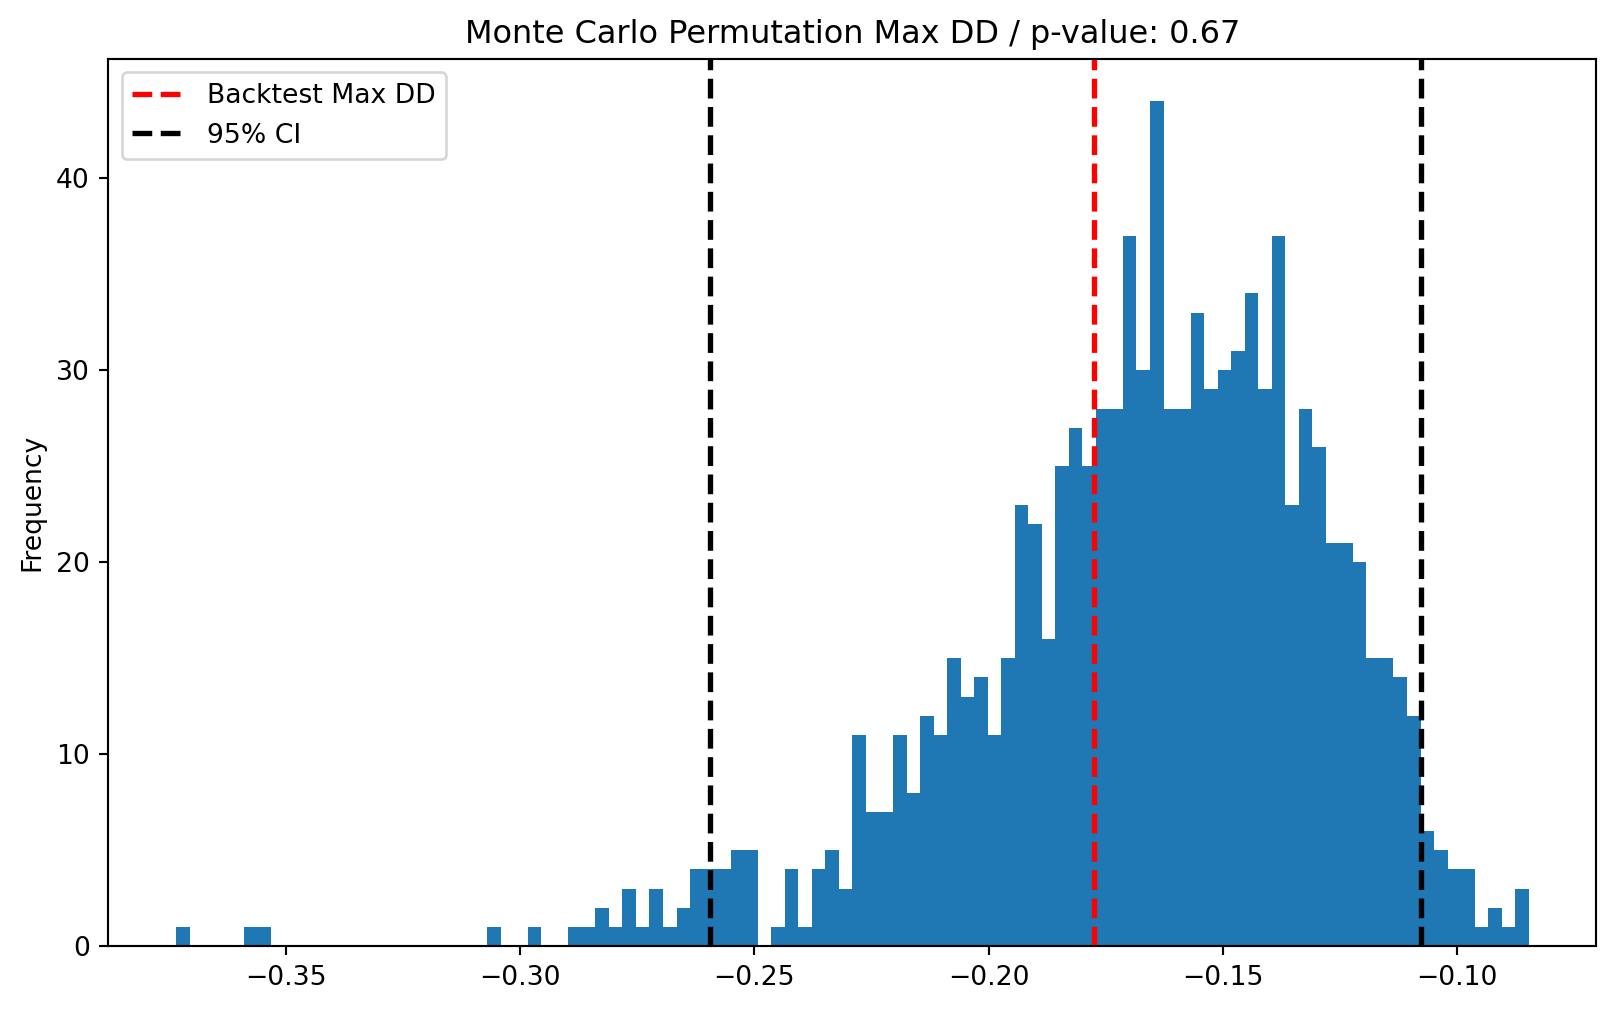

In [44]:
main.mcpyt_analysis(mcpyt, os_result.returns, ci=95)

Monte Carlo permutation analysis shows that the observed maximum drawdown of -17% is fairly typical relative to randomized return paths, with a p-value of 0.6. In other words, the backtest drawdown does not look unusually lucky or unusually harsh given the same return distribution, just a different ordering of returns. This suggests the reported drawdown is a plausible outcome for the strategy, while also reminding us that different return paths can still produce meaningfully deeper drawdowns.

## Conclusion

This study evaluated a cross-sectional sector momentum strategy using the 10 Fama-French industry portfolios across nearly a century of monthly data. Multiple momentum formation windows and portfolio concentration levels were tested in order to evaluate parameter robustness rather than optimize a single specification.

The in-sample analysis revealed several persistent patterns. Longer-term momentum signals, particularly ROC9, ROC12, and composite models, consistently outperformed shorter lookbacks across returns, Sharpe ratios, rolling profitability, and overall stability. Highly concentrated Top1 portfolios proved significantly unreliable in all momentum formation periods tested.

**Longer formation periods likely perform better because sector leadership tends to persist across business cycles and macroeconomic regimes. Shorter lookbacks are more exposed to noise, mean reversion, and temporary rotations.**

Among all tested configurations, ROC12 Top4 demonstrated the strongest balance between concentration, diversification, and parameter robustness, leading to its selection for out-of-sample evaluation.

Out-of-sample results were particularly interesting. While the momentum strategy achieved returns broadly similar to the Equal-Weight benchmark, it did so with substantially lower volatility and dramatically smaller drawdowns. During both the 2008 Global Financial Crisis and the 2020 COVID selloff, the strategy successfully avoided a large portion of the market decline by systematically rotating away from weak sectors and occasionally holding cash when momentum conditions deteriorated broadly.

**Can sector momentum improve risk-adjusted returns relative to Buy & Hold and Equal-Weight benchmarks?**
Overall, the evidence suggests that the primary benefit of sector momentum is not necessarily maximizing absolute returns, but improving portfolio efficiency through downside protection and smoother return behavior. As a tactical allocation overlay, the strategy appears capable of delivering equity-like returns with significantly improved risk-adjusted characteristics.